# Assignment 03 - Multi-Layer Perceptrons

### Due: Monday, Feb 9, before class

Name(s): Chang Min<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References
* Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. Nature, 323(6088), 533-536.
* PyTorch Documentation: https://pytorch.org/docs/stable/index.html
* Weights & Biases Documentation: https://docs.wandb.ai/

In [57]:
# <style>
# .todo-box {
#     background-color: #fcf8e3;
#     color: #000000;
#     border-left: 6px solid #f0ad4e;
#     padding: 10px;
#     margin-bottom: 0;
# }
#
# .todo-box h3 {
#     margin-top: 0;
# }
#
# .note-box {
#     background-color: #d1ecf1;
#     color: #000000;
#     border-left: 6px solid #0c5460;
#     padding: 10px;
#     margin-bottom: 0;
# }
#
# .warning-box {
#     background-color: #f8d7da;
#     color: #000000;
#     border-left: 6px solid #721c24;
#     padding: 10px;
#     margin-bottom: 0;
# }
#
# .section-box {
#     background-color: rgb(125, 233, 150);
#     color: #000000;
#     border-left: 6px solid #155724;
#     padding: 10px;
#     margin-bottom: 0;
# }
# </style>

---

# Week 3 - Multi-Layer Perceptrons & Modern Training

Last week, you built a Perceptron from scratch. You manually wrote the update rule, stepped through each training example, and discovered the fatal flaw: **linear separability**. The XOR problem could not be solved with a single perceptron. Whomp, whomp!!!

This week, let's skip over the AI Winter of the 70s and early 80s, fix that limitation and enter the modern era of neural networks with the **Multi-Layer Perceptron**.

**Key Objectives:**
1. **Understand Multi-Layer Perceptrons (MLPs):** How stacking layers with non-linear activations solves the XOR problem
2. **Differentiable Activation Functions:** Why Sigmoid and ReLU enable backpropagation
3. **Gradient Descent:** From manual error correction to automatic differentiation
4. **The PyTorch Training Loop:** The critical "Magic 5 Steps" that power all modern deep learning
5. **Experiment Tracking with W&B:** Start learning how the pros do it with MLOps best practices and platforms

> **Pedagogical Note:** This week marks a major transition. You will stop writing manual update rules and start using PyTorch's `torch.nn` and `torch.optim` modules. You will inherit from `nn.Module`, use `loss.backward()`, and let PyTorch compute gradients automatically. This is the way!

In [58]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.0+cpu


> From now on, let's be more mindful of using our GPUs whenever possible. This is going to become more important as the course progresses. It won't be very important in this assignment, and I wouldn't unnecessarily use it until you need to on Google Colab, since it can be costly.<br><br>
> For most of this assignment, you can use the CPU.<br><br>
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [59]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
# e.g. torch.device("cuda", 0) or torch.device("mps", 0)
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: False
No accelerator available, defaulting to CPU.


In [60]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [61]:
# Install any packages that are not part of the standard Google Colab environment here
if IN_COLAB:
    !pip install -q wandb
    pass

In [62]:
import wandb

In [63]:
# <div class="todo-box"><h1>TODO:</h1></div>

# TODO: Set your identity variables for W&B!

We're going to be using a new MLOps platform called Weights & Biases. Fill in the following variables below:

In [64]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# TODO: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

In [65]:
# <div class="section-box"><h1></h1></div>

# <div class="section-box">Background</div>

## The Historical Context: The AI Winter and Its Thaw

In 1969, Marvin Minsky and Seymour Papert published **"Perceptrons"**, a book that mathematically proved single-layer perceptrons could not solve problems like XOR. This revelation, combined with funding cuts and unrealistic expectations, triggered what became known as the **"AI Winter"** - a period of reduced funding and interest in neural network research that lasted over a decade.

But in 1986, a breakthrough paper changed everything. David Rumelhart, Geoffrey Hinton, and Ronald Williams published **"Learning representations by back-propagating errors"** in Nature. They showed that:
1. **Multi-layer networks** with non-linear activations could solve XOR and other non-linearly separable problems
2. **Backpropagation** - an algorithm using the chain rule of calculus - could efficiently compute gradients for all weights in a network
3. **Gradient descent** could optimize these networks automatically

This was not entirely new mathematics (backpropagation had been discovered independently multiple times), but their clear presentation and empirical results reignited the field. The modern era of neural networks had begun.

## Multi-Layer Perceptrons (MLPs)

An MLP is a neural network with one or more **hidden layers** between the input and output:

```
Input Layer → Hidden Layer(s) → Output Layer
```

**Key Insight:** The hidden layers learn to **transform** the input space. For XOR:
1. The hidden layer creates new features that make the problem linearly separable
2. The output layer draws a decision boundary in this transformed space

**Architecture Example (for XOR):**
* Input: 2 features (x₁, x₂)
* Hidden: 4 neurons with ReLU activation
* Output: 1 neuron with Sigmoid activation (for binary classification)

This is represented as: **2 → 4 → 1**

## The Universal Approximation Theorem

A stunning theoretical result: An MLP with a single hidden layer and a non-linear activation can approximate **any continuous function** to arbitrary precision (given enough neurons).

This doesn't mean one hidden layer is always best (deeper networks are often more efficient), but it proves MLPs are fundamentally powerful.

## From Error Correction to Gradient Descent

Last week, you used the **Perceptron Learning Rule**:

* $\mathbf{w}_{new} = \mathbf{w}_{old} + \eta \cdot \text{error} \cdot \mathbf{x}$

This rule is simple but has limitations:
* It only works with binary (0/1) errors
* It treats all mistakes equally (no concept of "how wrong")
* It cannot handle multiple layers

![Hills and Valleys](https://www.eg.bucknell.edu/~brk009/wp-content/uploads/2026/01/King_searching_for_valley.png)

Imagine Prof. King standing on a hillside in some dense fog. It's getting late, and he's eager to descend into the lowest valley he can find. He's a bit OCD, and doesn't really want to settle for just any local valley. He wants the best! "It's warmer down yonder, mate, and I needs to get my head out of the clouds! I guess I'll settle for anything lower than this!"  That dang fog! He can't see far. (Let's be honest - he really can't see far even on a sunny day.) He's not sure what direction to go in. So what does he do? Well, his vision is really limited, and it's getting dark. It's a step at a time:
1. Feel the slope under his feet (compute the gradient)
2. Take a step in whatever direction feels downhill (update your weights)
3. Repeat until you reach flat ground (convergence!)

That's all the acting you'll get from me this semester.<br>

Seriously, that's a pretty good picture of what gradient descent is all about. It's all about finding the lowest valley around, but understanding it's impossible to find the global lowest. You just hope the valley you find is pretty good. Or, perhaps the curiosity will get the best of you! You save the location of this local low point, and decide to go off in other directions for a bit, just to see if you have a better low. Maybe you'll find a lower point, maybe not. Either way, you're lower than you were when you first started this adventure!

If you haven't figured it out yet, the hilly landscape is a metaphor for the **loss** of your neural net. The loss varies depending on the weights. You're adjusting the weights in a way that lets you descend, slowly, into valleys of lower losses!

### Gradient Descent

**Gradient Descent** is certainly more sophisticated than the basic error update rule of the perceptron. We'll cover it in class (or already covered it by the time you start this assignment!) We ignore the mathematical details for the assignment, since that is covered in class. Instead of correcting discrete errors, it:
1. Defines a **loss function** $L(\mathbf{w})$ that measures how wrong the model is. Technically, it's a differentiable function of the error, i.e. the difference between $y$ and $\hat{y}$. However it's more important for you to think of it indirectly as a function of weights! Why? The loss varies depending on the weights of your model.
2. Calculates the **gradient** $\nabla L$ - the direction of steepest increase in loss, given the weights.
3. Updates weights by moving in the **opposite** direction: $\mathbf{w}_{new} = \mathbf{w}_{old} - \eta \nabla L$. Yep, you'll use that same learning rate parameter $\eta$ again.

Perhaps this picture is a bit more of an accurate visual of what Gradient Descent is doing:

![GD Hills and Valleys](https://www.eg.bucknell.edu/~brk009/wp-content/uploads/2026/01/GD_hills_and_valleys-1.png)

The **learning rate** $\eta$ controls your step size. Too large, and you might overshoot the valley. Too small, and you'll take forever to descend. This hyperparameter is pretty important for convergence into a good spot.

## Why We Need Differentiable Activation Functions

The Perceptron's **step function** has a fatal flaw for gradient descent:

$f(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{otherwise} \end{cases}$

Its derivative is:
$f'(z) = \begin{cases} 0 & \text{everywhere except } z=0 \\ \text{undefined} & \text{at } z=0 \end{cases}$

Generally, we're not big fans of 0 gradients. A gradient of 0 means, *"Oh crap! I have no idea about which direction to move, so I'm going to stay put and assume I'm in a good spot."* Gradient descent cannot work with this. However, more challenging is that it is not fully differentiable. We need **differentiable** activation functions.

We'll start with these two quintessential activation functions:

### 1. Sigmoid Function
$\sigma(z) = \frac{1}{1 + e^{-z}}$

**Properties:**
* Output range: $(0, 1)$ - interpretable as probability
* Smooth approximation of the step function
* Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ - easy to compute!

**Drawbacks:**
* **Vanishing gradients**: For large $|z|$, the gradient approaches 0
* Outputs are centered around 0.5, not zero-centered. Thus, for many problems, it can be very slow to learn.

### 2. ReLU (Rectified Linear Unit)
$\text{ReLU}(z) = \max(0, z)$

This one became very popular with the rise of deep learning due being the most computationally efficient activation available.

**Properties:**
* Simple: just clip negative values to 0
* Derivative: $f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{otherwise} \end{cases}$
* Avoids vanishing gradients for positive inputs
* Computationally efficient

**Drawbacks:**
* "Dying ReLU" problem: if weights send the output negative, neurons can get stuck outputting 0, and likewise, the gradient becomes non-informative.

**Modern Practice:** ReLU, depsite its limitations if the input to the activation becomes negative, has done very well in practice. There have been a variety of improvements over the years, with Leaky ReLU or ELU often being a better choice. Sigmoid is typically only used in output layers for binary classification as its output ranges [0-1].

We will cover many more as we progress through the course. For now, we will stick to these two.

## Backpropagation: The Chain Rule in Action

Backpropagation computes gradients layer-by-layer using the **chain rule** of calculus. You saw this worked out carefully in class, so we will not repeat the derivation here!

> Notation here will be slightly different than our derivation in lecture. We used $y$ to representing activated outputs in the hidden layer, and $z$ as our activated outputs in the output layer. However, when dealing with AI and ML coding and engineering, we must be strict about reserving $y$ as our single target output, $\mathbf{y}$ our vector of target outputs (and likewise, $\hat{y}$ and $\mathbf{\hat{y}}$) for our scalar and multi-dimensional predictions)

Summarizing, we have the following variables:
* $W^{(j)}$ : the weights feeding into layer $j$
* $b^{(j)}$ : the biases for layer $j$
* $net^{(j)}$ : the weighted sum for the units in layer $j$
* $z^{(j)}$ : the activated output for a unit in layer $j$

Let's consider a simplistic multi-layer perceptron (MLP) with a hidden and output layer. Then, for a typical 2-layer MLP, we have the following series of vector and matrix computations, representing the **feedforward** algorithm:
* $net^{(1)} = W^{(1)}x + b^{(1)}$
* $z^{(1)} = \sigma(net^{(1)})$
* $net^{(2)} = W^{(2)}z^{(1)} + b^{(2)}$
* $\hat{y} = \sigma(net^{(2)})$
* $L = \text{Loss}(\hat{y}, y)$

Our aim: **minimize the loss with respect to the weights.**

In **backpropagation**, we are most interested in computing $\frac{\partial L}{\partial W}$, the partial derivative of our loss with respect to all of the weights. We saw in class it was slightly different for each matrix of weights between layers, with the most compute intensive computations in the first hidden layer

$\frac{\partial L}{\partial W^{(1)}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial net^{(2)}} \cdot \frac{\partial net^{(2)}}{\partial z^{(1)}} \cdot \frac{\partial z^{(1)}}{\partial net^{(1)}} \cdot \frac{\partial net^{(1)}}{\partial W^{(1)}}$

### Autograd to the rescue!

PyTorch's **autograd** system is what allows neural networks to learn by automatically calculating derivatives (gradients) for you.  
When you perform operations on tensors, PyTorch records those operations in a dynamic computation graph! Think of it as a "tape recorder" tracking each step.  
Each tensor has an attribute called `.requires_grad` which informs PyTorch to keep track of its history as your doing the forward pass of your data!

When you call `loss.backward()`, here’s what PyTorch does step-by-step, under the hood:  
1. It retraces the entire series of calculations you performed during the forward pass, making a dynamic computation graph as it goes.  
2. It applies the chain rule of calculus layer by layer, working backwards from your output (the loss) back through each operation and layer, to compute the gradient of the loss with respect to each parameter.  
3. The computed gradient for each parameter (i.e. all your weights and biases) is stored in that parameter’s `.grad` attribute.  

This means you don’t have to manually differentiate anything—the entire process is automated. You simply build your model, define your loss, and call `.backward()`; PyTorch handles the math!

You never have to derive these equations by hand (unless you're implementing a custom operation, or you like suffering.)

> If you want to become an AI engineer, it is essential to master backpropagation and gradient descent. This is the most important algorithm at the heart of how neural networks actually learn. Step by step, it moves the model's parameters in the direction that reduces the loss (and the error) of your model. Understanding gradient descent demystifies how models update, what learning rates mean, how the network can get stuck (in local minima or saddle points), and why some architectures or losses require specialized optimization techniques. It helps you understand terms like *vanishing gradient*, or *exploding gradient*. Ultimately, every breakthrough in training deep networks has come from a deep grasp of how gradients flow and how descent works—so to build, diagnose, and improve real neural networks reliably, you absolutely need this foundation.

## The PyTorch Training Loop: The "Magic 5 Steps"

Every PyTorch training loop follows the same pattern:

```python
for epoch in range(num_epochs):
    # 1. Clear old gradients
    optimizer.zero_grad()
    
    # 2. Forward pass (on full dataset)
    predictions = model(X)
    
    # 3. Calculate loss
    loss = criterion(predictions, y)
    
    # 4. Backward pass (compute gradients)
    loss.backward()
    
    # 5. Update weights
    optimizer.step()
```

**Why each step matters:**
1. **`zero_grad()`**: Gradients accumulate by default. Every time you pass data through your model, losses for the gradient calculations accumulate! Clear them before each batch.
2. **Forward pass**: Compute predictions. PyTorch builds the computation graph here and accumulates your gradients.
3. **Loss calculation**: Quantify how wrong we are.
4. **`backward()`**: From the loss, let autograd do it's magic, computing all gradients via backpropagation.
5. **`step()`**: Optimizer updates parameters using the gradients.

In [66]:
# <div class="section-box"><h1></h1></div>

# <div class="section-box">Lab - Building Your First MLP</div>

## Section 1: Differentiable Activation Functions

Before we build our MLP, let's understand activation functions by implementing and visualizing them.

### 1.1 Implementing Activations and Their Derivatives

In [67]:
# <div class="todo-box"><h3>TODO</h3></div>

### Question Set 1

1. Complete the functions below to implement `sigmoid`, `relu`, and their derivatives. The derivatives should be implemented as separate functions (not using autograd).

In [68]:
# ANSWER
def sigmoid(z):
    """
    Applies the sigmoid activation function.

    Args:
        z (torch.Tensor): Input tensor.

    Returns:
        torch.Tensor: Output after sigmoid activation, in range (0, 1).
    """
    # TODO: Finish me!
    return (1 / (1 + torch.exp(-z)))


def sigmoid_derivative(z):
    """
    Computes the derivative of the sigmoid function.

    Args:
        z (torch.Tensor): Input tensor.

    Returns:
        torch.Tensor: Derivative of sigmoid at z.
    """
    # TODO: Finish me!
    return (torch.exp(-z) / (1 + torch.exp(-z)) ** 2)


def relu(z):
    """
    Applies the ReLU activation function.

    Args:
        z (torch.Tensor): Input tensor.

    Returns:
        torch.Tensor: Output after ReLU activation, max(0, z).
    """
    # TODO: Finish me!
    return torch.clamp(z, min=0)

def relu_derivative(z):
    """
    Computes the derivative of the ReLU function.

    Args:
        z (torch.Tensor): Input tensor.

    Returns:
        torch.Tensor: Derivative of ReLU at z (1 if z > 0, else 0).
    """
    # TODO: Finish me!
    return (z > 0).float()

# Test the functions
z_test = torch.linspace(-5, 5, 100)
print("Sigmoid tests:")
print(f"  sigmoid(0) = {sigmoid(torch.tensor(0.0)):.4f} (should be ~0.5)")
print(f"  sigmoid(5) = {sigmoid(torch.tensor(5.0)):.4f} (should be ~0.99)")
print(f"  sigmoid_derivative(0) = {sigmoid_derivative(torch.tensor(0.0)):.4f} (should be 0.25)")
print("\nReLU tests:")
print(f"  relu(-5) = {relu(torch.tensor(-5.0)):.4f} (should be 0)")
print(f"  relu(5) = {relu(torch.tensor(5.0)):.4f} (should be 5)")
print(f"  relu_derivative(5) = {relu_derivative(torch.tensor(5.0)):.4f} (should be 1)")
print(f"  relu_derivative(-5) = {relu_derivative(torch.tensor(-5.0)):.4f} (should be 0)")

Sigmoid tests:
  sigmoid(0) = 0.5000 (should be ~0.5)
  sigmoid(5) = 0.9933 (should be ~0.99)
  sigmoid_derivative(0) = 0.2500 (should be 0.25)

ReLU tests:
  relu(-5) = 0.0000 (should be 0)
  relu(5) = 5.0000 (should be 5)
  relu_derivative(5) = 1.0000 (should be 1)
  relu_derivative(-5) = 0.0000 (should be 0)


### 1.2 Visualizing Activations and Their Derivatives

Let's visualize these functions to understand their behavior.

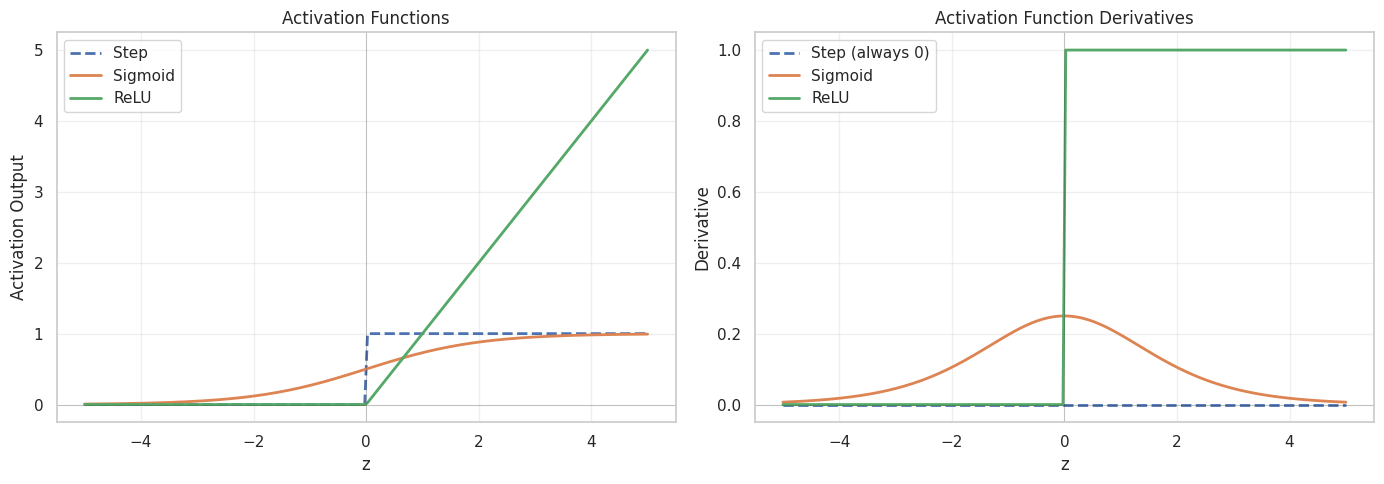

In [69]:
z = torch.linspace(-5, 5, 200)

# Calculate activations
step_output = (z > 0).float()
sigmoid_output = sigmoid(z)
relu_output = relu(z)

# Calculate derivatives
sigmoid_deriv = sigmoid_derivative(z)
relu_deriv = relu_derivative(z)
step_deriv = torch.zeros_like(z)  # Derivative is 0 everywhere (except undefined at 0)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot activations
ax1.plot(z, step_output, label='Step', linewidth=2, linestyle='--')
ax1.plot(z, sigmoid_output, label='Sigmoid', linewidth=2)
ax1.plot(z, relu_output, label='ReLU', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax1.set_xlabel('z')
ax1.set_ylabel('Activation Output')
ax1.set_title('Activation Functions')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot derivatives
ax2.plot(z, step_deriv, label='Step (always 0)', linewidth=2, linestyle='--')
ax2.plot(z, sigmoid_deriv, label='Sigmoid', linewidth=2)
ax2.plot(z, relu_deriv, label='ReLU', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax2.set_xlabel('z')
ax2.set_ylabel('Derivative')
ax2.set_title('Activation Function Derivatives')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
* **Step function**: Sharp transition at 0. Derivative is 0 everywhere (useless for gradient descent).
* **Sigmoid**: Smooth S-curve. Derivative is maximum at z=0 (0.25) and approaches 0 for large |z|, leading to the **vanishing gradient problem** if the logit gets too large. When the logit gets too positive or negative, the sigmoid flattens out and gradients approach 0, and learning nearly stops.
* **ReLU**: Linear for positive values (derivative is 1), zero for negative values (derivative is 0). This means ReLU avoids the vanishing gradient problem on the positive side, allowing for efficient learning. However, for negative input values (z < 0), the derivative is always 0. This can lead to the **dying ReLU** problem, where neurons remain inactive (output and gradient are zero), effectively removing them from learning if their inputs are persistently negative.

**Summary:** While step and sigmoid activations both present obstacles to learning (step is non-differentiable and always flat) sigmoid suffers from gradients vanishing at extremes, and ReLU offers a partial solution but introduces its own challenge: complete inactivity for persistently negative logits.

Continuing the question set, let's explore why derivatives matter for learning

2. Carefully read the function `demonstrate_gradient_effect`, and complete the `# TODO` sections. It a very, very simple function only designed to demonstrate a problem you need to be aware of when using

In [70]:
def demonstrate_gradient_effect(z_value, learning_rate=0.1):
    """
    Demonstrates how gradient magnitude affects weight updates for different activations.

    Args:
        z_value (float): The input value to test.
        learning_rate (float): The learning rate for weight updates.

    Returns:
        pd.DataFrame: Results showing gradient and weight update for each activation.
    """
    z = torch.tensor([z_value], requires_grad=False)

    # For sigmoid
    sig_out = sigmoid(z)
    sig_grad = sigmoid_derivative(z)

    # For ReLU
    relu_out = relu(z)
    relu_grad = relu_derivative(z)

    # TODO: Simulate weight update: w_new = w_old - lr * gradient
    # Assuming gradient of loss w.r.t. activation is 1.0 for simplicity
    sig_weight_change = sig_out - sig_grad
    relu_weight_change = relu_out - relu_grad


    # Return a dataframe with the results
    results = pd.DataFrame({
        'Activation': ['Sigmoid', 'ReLU'],
        'Output': [sig_out.item(), relu_out.item()],
        'Gradient': [sig_grad.item(), relu_grad.item()],
        'Weight Change (lr=0.1)': [sig_weight_change, relu_weight_change]
    })

    return results


# Test with different z values
print("At z = -3 (large negative):")
print(demonstrate_gradient_effect(-3))
print("\nAt z = 0:")
print(demonstrate_gradient_effect(0))
print("\nAt z = 0.1 (small positive):")
print(demonstrate_gradient_effect(0.1))
print("\nAt z = 3 (large positive):")
print(demonstrate_gradient_effect(3))

At z = -3 (large negative):
  Activation    Output  Gradient Weight Change (lr=0.1)
0    Sigmoid  0.047426  0.045177       [tensor(0.0022)]
1       ReLU  0.000000  0.000000           [tensor(0.)]

At z = 0:
  Activation  Output  Gradient Weight Change (lr=0.1)
0    Sigmoid     0.5      0.25       [tensor(0.2500)]
1       ReLU     0.0      0.00           [tensor(0.)]

At z = 0.1 (small positive):
  Activation    Output  Gradient Weight Change (lr=0.1)
0    Sigmoid  0.524979  0.249376       [tensor(0.2756)]
1       ReLU  0.100000  1.000000      [tensor(-0.9000)]

At z = 3 (large positive):
  Activation    Output  Gradient Weight Change (lr=0.1)
0    Sigmoid  0.952574  0.045177       [tensor(0.9074)]
1       ReLU  3.000000  1.000000           [tensor(2.)]


**Key Insight:** When z is large (positive or negative), Sigmoid's gradient becomes very small, leading to tiny weight updates. This is the **vanishing gradient problem**. ReLU maintains a gradient of 1 for all positive values, enabling faster learning, but for negative values, it may lead to the **dying ReLU** problem.

## Section 2: Your First `nn.Module` MLP

Now we transition from manual implementations to PyTorch's `nn.Module` framework. This is how all modern neural networks are built.

### 2.1 Understanding `nn.Module`

Every PyTorch model inherits from `nn.Module`. This base class provides:
* Automatic parameter tracking
* GPU support
* Integration with autograd
* Utilities like `.train()` and `.eval()` mode switching

The two methods you **must** implement:
1. **`__init__`**: Define the layers and activations (the "parts")
2. **`forward`**: Define the computational flow (the "assembly")

Below is a bare bones, complete class called `SimpleMLP`. This is a basic 2-layer MLP with one hidden layer. Notice the hidden units have an `ReLU` activation, but the output does not.

In [71]:
# ANSWER
class SimpleMLP(nn.Module):
    """
    A simple multi-layer perceptron with one hidden layer.

    Architecture: input_dim → hidden_dim (ReLU) → output_dim

    Attributes:
        layer1 (nn.Linear): First linear layer.
        relu (nn.ReLU): ReLU activation function.
        layer2 (nn.Linear): Second linear layer (output).
    """

    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Initializes the SimpleMLP.

        Args:
            input_dim (int): Number of input features.
            hidden_dim (int): Number of neurons in hidden layer.
            output_dim (int): Number of output neurons.
        """
        super(SimpleMLP, self).__init__()

        # Define layers
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).

        Returns:
            torch.Tensor: Output logits of shape (batch_size, output_dim).
        """
        # Pass through first layer
        x = self.layer1(x)
        # Apply ReLU activation
        x = self.relu(x)
        # Pass through output layer
        x = self.layer2(x)
        return x



Then, we can instantiate our first MLP:

In [72]:
# Instantiate a 2-4-1 model named model. Iterate through the model's parameters and print their shapes.
model = SimpleMLP(input_dim=2, hidden_dim=4, output_dim=1)
print(model)
print(f"\nModel parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: shape {param.shape}")

# Test with random data
test_input = torch.randn(3, 2)  # Batch of 3 samples, 2 features each
test_output = model(test_input)
print(f"\nTest input shape: {test_input.shape}")
print(f"Test output shape: {test_output.shape}")
print(f"Test output:\n{test_output}")

# Delete the model.
del model

SimpleMLP(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)

Model parameters:
  layer1.weight: shape torch.Size([4, 2])
  layer1.bias: shape torch.Size([4])
  layer2.weight: shape torch.Size([1, 4])
  layer2.bias: shape torch.Size([1])

Test input shape: torch.Size([3, 2])
Test output shape: torch.Size([3, 1])
Test output:
tensor([[0.6994],
        [0.5415],
        [1.1476]], grad_fn=<AddmmBackward0>)


### Comparing to HW02 Manual Implementation

In HW02, you wrote:
```python
self.weights = torch.randn(input_dim)
self.bias = torch.zeros(1)
z = torch.matmul(X, self.weights) + self.bias
```

In PyTorch, `nn.Linear` does this for you:
* Initializes weights and bias automatically
* Handles the matrix multiplication
* Registers parameters so optimizers can find them

**Your HW02 Perceptron class effectively collapses to a single line:**
```python
self.layer = nn.Linear(input_dim, 1)
```

### 2.2 Back to the XOR problem with an MLP

In [73]:
# <div class="todo-box"><h3>TODO</h3></div>

### Question Set 2

So, let's see if a simple 2 -> 4 -> 1 model can solve XOR! For this exercise, we will only use our above `SimpleMLP` class to create the model and see what the boundary looks like before training.

1. Define the XOR dataset (same as HW02).
2. Create a `SimpleMLP` with architecture 2 → 4 → 1.
3. Visualize the decision boundary BEFORE training using the provided function.

In [74]:
# ANSWER
# Define XOR data as an `X_xor` tensor of inputs, and `y_xor` tensor of labels.
X_xor = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
], dtype=torch.float32)

y_xor = torch.tensor([[0.], [1.], [1.], [0.]], dtype=torch.float32)

# Show the data
print("XOR Dataset:")
print("X:", X_xor)
print("y:", y_xor.squeeze())

# Create model
# TODO: Create a model named model_xor with architecture 2 → 4 → 1
model_xor = SimpleMLP(input_dim=2, hidden_dim=4, output_dim=1)



XOR Dataset:
X: tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
y: tensor([0., 1., 1., 0.])


Again, we'll provide a basic plotting function so you can visualize the decision boundary:

In [75]:
def plot_decision_boundary_mlp(model, X, y, title="Decision Boundary"):
    """
    Plots the decision boundary for a binary classification model.

    Args:
        model (nn.Module): Trained model.
        X (torch.Tensor): Input features of shape (N, 2).
        y (torch.Tensor): True labels of shape (N, 1) or (N,).
        title (str): Plot title.
    """
    plt.figure(figsize=(8, 6))

    # Ensure y is 1D
    if y.dim() > 1:
        y = y.squeeze()

    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 100),
                            torch.linspace(y_min, y_max, 100),
                            indexing='ij')

    # Flatten grid and predict
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)
    model.eval()
    with torch.no_grad():
        Z = torch.sigmoid(model(grid))  # Apply sigmoid to get probabilities
    Z = Z.reshape(xx.shape)

    # Plot decision boundary (probability = 0.5)
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    # Plot data points
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', s=200, edgecolors='k', marker='o', label='Class 0')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', s=200, edgecolors='k', marker='s', label='Class 1')

    # Calculate and display accuracy
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X)) > 0.5).float().squeeze()
    accuracy = (preds == y).float().mean().item() * 100

    plt.text(0.02, 0.98, f'Accuracy: {accuracy:.1f}%',
             transform=plt.gca().transAxes,
             fontsize=13, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


And, visualizing the untrained model...

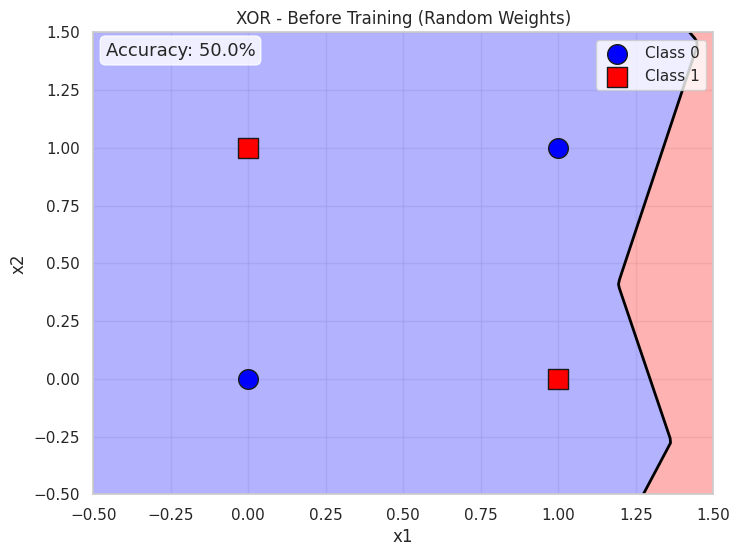

In [76]:
# Visualize before training
plot_decision_boundary_mlp(model_xor, X_xor, y_xor, "XOR - Before Training (Random Weights)")

As expected, the untrained model with random weights cannot solve XOR. Now let's train it!

## Section 3: The Modern Training Loop

### 3.1 Loss Functions (a.k.a. Criterion)

A **loss function** (or **cost function**) measures how wrong your model is. It takes predictions and true labels as input and outputs a single number (the loss). Lower is better.
In PyTorch and other machine learning frameworks, these loss functions are referred to as the **criterion**.

We will come across a varity of criterion functions for training. The criterion you use depends on the type and dimensionality of the target variable(s). For binary classification, we set up our `forward` method to output logits (raw output) as the final output, i.e. you do *not* specify an activation function on the output layer! Why? The most common criterion for binary classification problmes is the **Binary Cross-Entropy with Logits Loss** (`nn.BCEWithLogitsLoss`):
* Combines sigmoid activation and binary cross-entropy in one operation (which is why you do NOT specify a sigmoid in the output!)
* Numerically stable (avoids floating-point errors)
* Standard choice for binary classification

**Why "with Logits"?**
* Your model outputs raw scores (logits)
* The loss function applies sigmoid internally
* More numerically stable than applying sigmoid first, then calculating loss

**Common loss functions**

Here's a table of a few common loss functions for common machine learning tasks:

| Task                     | Loss (Criterion)              | Model Output (Input) | Target Format                                            | Notes                                                         |
|--------------------------|-------------------------------|----------------------|----------------------------------------------------------|---------------------------------------------------------------|
| Binary Classification    | `nn.BCEWithLogitsLoss`        | logits (no sigmoid)  | Float (0 or 1), shape = (N, 1) or (N,)                  | Combines sigmoid + binary cross-entropy in one, numerically stable |
| Multiclass Classification| `nn.CrossEntropyLoss`         | logits (no softmax)  | Long (class indices), shape = (N,)                       | **Each sample: single integer (class index); shape = (N,)** <br>For K classes, targets should **not** be one-hot or (N, K) for this loss.      |
| Regression               | `nn.MSELoss`                  | predictions          | Float (continuous), shape = (N, outputs) or (N,)          | Standard Mean Squared Error (L2 loss)                         |
| Multilabel Classification| `nn.BCEWithLogitsLoss`        | logits (no sigmoid)  | Float (0 or 1), shape = (N, num_labels) (multi-output)    | Handles multiple binary labels per sample, applies sigmoid    |

<br>

> Choosing the correct criterion (or loss function) is crucial for training your neural network effectively. The criterion guides your model during learning by quantifying how well its predictions match the true labels. If you use the wrong loss function for your problem type, your model may learn poorly, fail to converge, or give misleading results. For example, regression problems typically use mean squared error, while classification tasks often require cross-entropy-based losses. Understanding your task and matching it with the appropriate criterion is a foundational step for successful model training. There are a lot to choose from, and it's a common source of confusion when first creating neural networks. Don't worry! You'll get plenty of experience with a variety of them.

### 3.2 Optimizers

An **optimizer** updates the model's parameters (i.e. the model weights and biases) based on gradients of the loss function, with the aim being the obvious - minimize the loss! Like loss functions, PyTorch provides *many* optimizers in `torch.optim`. The most common:

* **SGD (Stochastic Gradient Descent)**: $w_{new} = w_{old} - \eta \nabla L$
  - The standard gradient
  - Simple and effective
  - Requires careful learning rate tuning

* **Adam (Adaptive Moment Estimation)**:
  - SGD with momentum plus an adaptive learning rate for each parameter
  - Usually works well with default settings
  - Most popular choice in practice

> What is **momentum** in optimizers?
>
> **Momentum** is another training hyperparameter in gradient descent methods. It's a technique used in optimization to speed up training and help your neural network models escape local minima or shallow regions in the loss landscape. It is especially helpful when gradients vary in different directions or when you encounter "ravines" (areas where the loss function curves more steeply in one dimension than another).

For this assignment, we'll start with **SGD** to understand the basics, then experiment with Adam.

**Adam tends to be the most common optimizer in practice. There is a few variants of Adam available
| Optimizer Name | `torch.optim` Name    | Notes                                                                                       |
|---------------|-----------------------|---------------------------------------------------------------------------------------------|
| SGD           | `torch.optim.SGD`     | Simple gradient descent; good baseline; can use momentum for stability/speed                |
| Adam          | `torch.optim.Adam`    | Most popular adaptive method; works well in most scenarios                                  |
| RMSprop       | `torch.optim.RMSprop` | Adaptive learning rate; helps in recurrent nets, mitigates oscillations                     |

<br>

> **What optimizer should you use for mini-batch or full-batch gradient descent?**
>
> In practice, both SGD (`torch.optim.SGD`) and Adam (`torch.optim.Adam`) can be used for mini-batch or full-batch training. However, SGD with momentum or Adam are particularly popular choices for mini-batch gradient descent, as they handle the noisiness of mini-batch updates well and help accelerate convergence. For full-batch (where the entire dataset is used for each parameter update), plain SGD or variants can also be effective, but computational cost is high for large datasets.
>
> In summary: **Adam** is often the preferred optimizer for most mini-batch (and even full-batch) training scenarios due to its adaptability and efficiency, but SGD (with or without momentum) is also widely used—especially when fine control over optimization dynamics is needed.


In [77]:
# <div class="todo-box"><h3>TODO</h3></div>

### Question Set 3

1. Remember the `model_xor` model you created. Let's see what the loss function reports. Follow the `# TODO` sections below.

In [78]:
# ANSWER
# TODO: Get the logits and the activated (sigmoid) predictions from untrained model (remember no_grad!)
model_xor.eval()
with torch.no_grad():
    logits = model_xor.forward(X_xor)
    predictions = sigmoid(logits)



# TODO: Print the logits and probabilities (i.e. the activated predictions)
print(f"Logits: {logits}")
print(f"Pred: {predictions}")


# TODO: Calculate loss using nn.BCEWithLogitsLoss and print it
criterion = nn.BCEWithLogitsLoss()
print(f"Loss: {criterion(logits, y_xor)}")




Logits: tensor([[-0.2249],
        [-0.1647],
        [-0.0374],
        [-0.0701]])
Pred: tensor([[0.4440],
        [0.4589],
        [0.4907],
        [0.4825]])
Loss: 0.6841559410095215


**Interpretation:** Binary cross entropy (BCE) measures how well the predicted probabilities match the true binary labels, with lower values indicating better predictions. BCE is minimized when the model outputs are close to the true labels (0 or 1). For a random model predicting 0.5 for both classes, the loss is -ln(0.5) ≈ 0.693, which is the maximum uncertainty. Therefore, the untrained model, which hasn't learned class structure and outputs values around 0.5, should also produce a loss close to 0.69. **You're Loss should be pretty darn close to 0.69!**

2. Now, create an optimizer for the XOR model. Use SGD with learning rate 0.1.

In [79]:
# ANSWER
# TODO: Create optimizer
optimizer = torch.optim.SGD(model_xor.parameters(), lr=0.1)


# Print the optimizer and the parameters to be optimized (iterate through `model_xor.named_parameters()`)
print("Optimizer created:")
print(optimizer)
print("\nParameters to be optimized:")
for name, param in model_xor.named_parameters():
    print(f"  {name}: shape {param.shape}, requires_grad={param.requires_grad}")

Optimizer created:
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Parameters to be optimized:
  layer1.weight: shape torch.Size([4, 2]), requires_grad=True
  layer1.bias: shape torch.Size([4]), requires_grad=True
  layer2.weight: shape torch.Size([1, 4]), requires_grad=True
  layer2.bias: shape torch.Size([1]), requires_grad=True


3. Time to set up a full training function! Carefully complete the function below, paying attention to the `# TODO` steps.

In [80]:
# ANSWER
def train_model(model, X, y, criterion, optimizer, epochs=1000, print_every=100):
    """
    Trains a PyTorch model using the standard training loop.

    Args:
        model (nn.Module): Model to train.
        X (torch.Tensor): Input features.
        y (torch.Tensor): True labels.
        criterion: Loss function.
        optimizer: Optimizer.
        epochs (int): Number of training epochs.
        print_every (int): Print loss every N epochs.

    Returns:
        list: History of losses.
    """
    model.train()  # Set model to training mode
    loss_history = []

    for epoch in range(epochs):
        # TODO: STEP 1 - Clear old gradients
        optimizer.zero_grad()

        # TODO: STEP 2 - Forward pass
        pred = model(X)

        # TODO: STEP 3 - Calculate loss
        loss = criterion(pred, y)

        # TODO: STEP 4 - Backward pass (compute gradients)
        loss.backward()

        # TODO: STEP 5 - Update weights
        optimizer.step()

        # Record loss
        loss_history.append(loss.item())

        # Print progress
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

    return loss_history



4. Train the `model_xor` for 2000 epochs, printing every 100 epochs, and plot the loss curve (which is easy since the function returns a list of losses computed after every epoch!)

Training XOR model...
Epoch 100/2000, Loss: 0.5978
Epoch 200/2000, Loss: 0.4657
Epoch 300/2000, Loss: 0.3166
Epoch 400/2000, Loss: 0.1746
Epoch 500/2000, Loss: 0.0931
Epoch 600/2000, Loss: 0.0565
Epoch 700/2000, Loss: 0.0380
Epoch 800/2000, Loss: 0.0277
Epoch 900/2000, Loss: 0.0214
Epoch 1000/2000, Loss: 0.0172
Epoch 1100/2000, Loss: 0.0143
Epoch 1200/2000, Loss: 0.0122
Epoch 1300/2000, Loss: 0.0105
Epoch 1400/2000, Loss: 0.0092
Epoch 1500/2000, Loss: 0.0082
Epoch 1600/2000, Loss: 0.0074
Epoch 1700/2000, Loss: 0.0067
Epoch 1800/2000, Loss: 0.0061
Epoch 1900/2000, Loss: 0.0056
Epoch 2000/2000, Loss: 0.0052


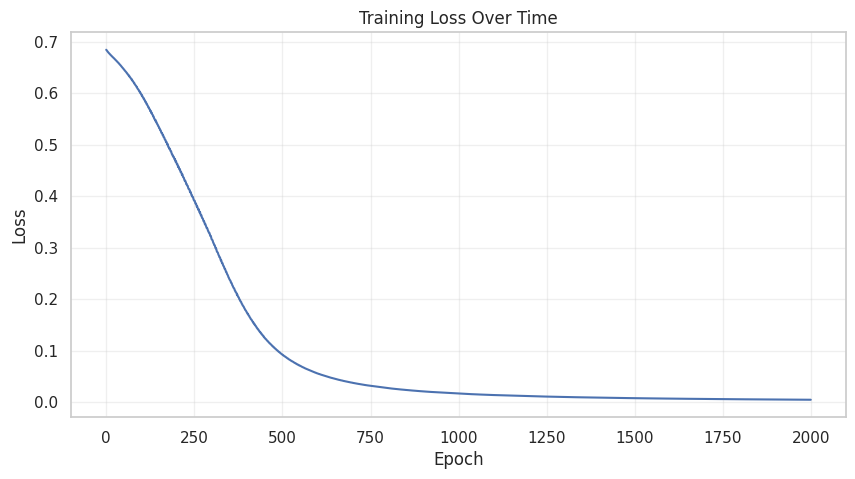

In [81]:
# Train the model
print("Training XOR model...")
# TODO: Train the model
loss_history = train_model(model=model_xor, X=X_xor, y=y_xor, criterion=criterion, optimizer=optimizer, epochs=2000, print_every=100)


# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

5. Plot the decision boundary of the trained model

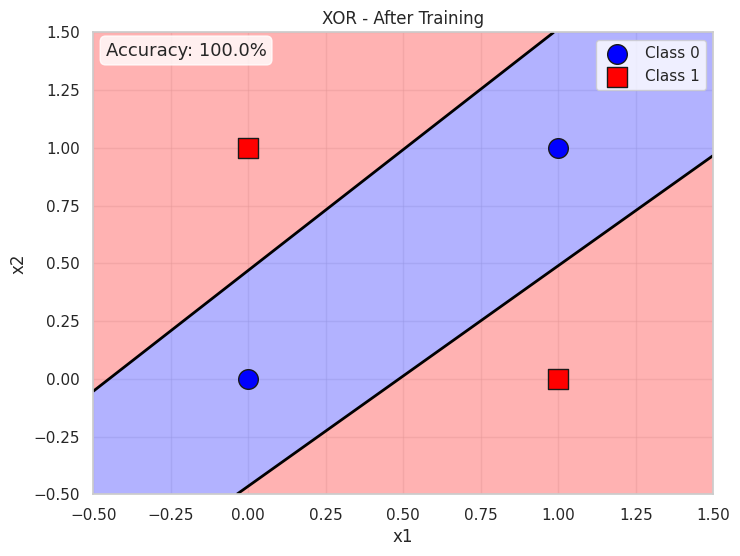

In [82]:
# Visualize decision boundary after training
plot_decision_boundary_mlp(model_xor, X_xor, y_xor, "XOR - After Training")

**Success!** (Hopefully! There is a random chance that it will not converge. If not, run it again.) The MLP has solved XOR. What was impossible for a single perceptron is now trivial for a 2-layer network with non-linear activation.

**What happened during training?**
1. The hidden layer learned to create new features that make XOR linearly separable
2. The output layer learned a linear decision boundary in this transformed space
3. Backpropagation efficiently computed gradients for all 4 layers of weights and biases
4. Gradient descent iteratively adjusted parameters to minimize loss

## Section 4: Introducing Weights & Biases (W&B)

### Machine Learning in the Real-World: Experiment Tracking Matters!

You've successfully trained your first MLP! But imagine this scenario:

**Monday:** You train a model with learning rate 0.1, get 95% accuracy. You save the code and move on.

**Wednesday:** You try learning rate 0.01, get 97% accuracy. Great! But... wait, what was the exact architecture you used on Monday? Did you use ReLU or Sigmoid? What was the hidden layer size?

**Friday:** Your teammate asks: "Which hyperparameters worked best?" You stare at your terminal history, trying to remember which `print()` statement belonged to which experiment.

**Next Week:** You need to reproduce Monday's results for a paper submission. You have no idea which random seed you used, or whether you normalized the data differently.

Some refer to this adhoc, clueless approach to model design, development and optimization in machine learning as "Dumbass ML". You must develop discipline to make it in the ML and AI world. The "hacking" mentality of randomly trying hyperparameters and hoping for the best doesn't cut it. Learning how to use modern AI and ML tools will serve you greatly, getting you out of the "old school" habits of machine learning before it becomes a bad habit. **This is the problem W&B solves.**

### What is Weights & Biases?

**Weights & Biases (W&B)** is an MLOps platform that automatically tracks everything about your machine learning experiments. This can be used with any machine learning pipeline or platform. It's not just for PyTorch. You can automatically log:

* **Metrics:** Loss, accuracy, and any custom metrics you define - automatically logged and visualized
* **Hyperparameters:** Learning rate, batch size, architecture choices - all saved with each run
* **System Info:** GPU usage, memory consumption, training time
* **Code & Environment:** Git commits, Python packages, random seeds
* **Visualizations:** Loss curves, confusion matrices, decision boundaries, gradient histograms
* **Collaboration:** Share dashboards with teammates, compare experiments side-by-side

**Why We're Learning This Now**

In research, grad school in ML, and in industry, **experiment tracking is not optional** - it's a fundamental skill. Companies including OpenAI, NVidia, Meta, Aleph Alpha, and Mistral AI are all using W&B now to track and optimize models. It's not just AI companies! Amazon, GSK, BMW Group, Fujitsu, and countless other companies are using it! **Putting W&B next to PyTorch on your resume will look good!** These companies are using it to:

- Track thousands of experiments across teams
- Reproduce results months later
- Identify which hyperparameters actually matter
- Debug training failures (e.g., "Why did this run diverge?")
- Make data-driven decisions about model improvements

We will start slow. But we're going to use it, repeatedly. I decided to introduce W&B **early** in this course because:
1. **Professional Practice:** You'll use this in internships, research, and jobs
2. **Better Learning:** Visualizing training helps you understand what's happening
3. **Time Saver:** No more scrolling through terminal output to find results
4. **Portfolio Building:** W&B dashboards make great additions to your GitHub portfolio



In [83]:
# <div class="todo-box"><h2>IMPORTANT: Setting up your W&B account</h2></div>

### Setting Up W&B: Step-by-Step Guide

Follow these instructions - you only need to do this once!

1. Create a free academic account:<br>
    a. Go to https://wandb.ai/site <br>
    b. Click "Sign Up". SIGN UP WITH YOUR UNIVERSITY E-MAIL ADDRESS! Use the same one you use for this course. You should quality for free academic use of W&B. (You can also sign up with GitHub, Google, or email, as long as they are tied to your Bucknell e-mail, but probably want to sign up with an e-mail address to be sure.) Confirm the e-mail when you're done.<br>

2. Generate your API key<br>
    a. On the W&B site, click your profile picture (top right), choose **User Settings** from the menu. Scroll down until you find the section **API Keys**.<br>
    b. Click **New key**. Give it whatever name you want, such as `joe-macbook-csci357`. If you intend to use your account for different purposes, or different machines, you'll need a key for each.<br>
    c. Click **Create**, then copy the key and store it someplace safe. You'll need it in the next step.

#### Running in Google Colab?
3. `wandb` is not part of the standard Colab environment. The code at the top of this notebook takes care of it for you. Be sure you can locate the cell above that conditionally installs `wandb` if you're in Colab. This is how you'll install additional packages in Colab in the future. As long as you run this first as is, you should be good to go.
4. The very next cell below will login to your wandb account. Be sure you watch for a popup either in the cell or as a popup window. It'll first ask you:
```
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
```
Choose 2. Then it'll ask you to paste your API key. You should be all set.

#### Running on your local machine?
3. Confirm that you have wandb installed by pip in your csci357 environment. This should be set up already, but just incase:<br>
    a. Open your terminal, and make sure your csci357 environment is the active conda environment<br>
    b. `pip list | grep wandb` - this should show that it's installed. If not, run `uv pip install wandb`<br><br
4. Login to your wandb account from your development environment<br>
    a. Open a terminal window<br>
    b. Be sure you are in your `csci357` conda environment. Run `wandb login`.<br>
    NOTE: If for some reason you are doing this again and want to force a new login, type `wandb login --relogin`)<br>
5. Stop and restart your kernel.

After you log in, you should see a confirmation about being successfully logged into your wandb account!

**That's it! You should see a confirmation that you are connected to wandb with your account. You should not need to run these steps on your computer again (unless you change your API key, or you are running a new Colab instance.)**

#### About Your W&B API Key

Your Weights & Biases (W&B) API key is a unique string that identifies **you** when your code uploads experiment results to your W&B account. Think of it like a password: it lets your computer communicate with your W&B dashboard.

When you login to W&B and paste your key, W&B stores it safely in a config file on your computer (usually at `~/.netrc` or sometimes in a wandb-specific directory). This happens automatically—you don't need to remember the file location for daily use.

**Why does this matter?** If someone else gets your API key, they could upload, change, or access your W&B projects as if they were you. So:  
- **Never share your key publicly (e.g., putting it in GitHub or sending it in chat)!**  
- If you ever think your key is compromised, go to your W&B account settings and delete/regenerate your API key.

#### When you would need to log in again
* If you explicitly log out or delete/modify the credentials in `~/.netrc`, W&B will ask you to log in again.
* If you switch to a different user account or machine (new laptop, remote server, Colab, etc.), you need to configure the key there once as well.
* You can force a fresh login with `wandb login --relogin` if you ever change users or keys.



In [84]:
# Running in Colab? Then login here!
if IN_COLAB:
    wandb.login()

wandb: Currently logged in as: cb073 (cb073-bucknell-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### The W&B Workflow (Simplified)

Using W&B is incredibly simple - just three steps:

```python
# 1. Initialize a run with an entity, project, and run name (creates a dashboard)
wandb.init(entity="my-team",
           project="my-project",
           name="experiment-1")

# 2. Log metrics during training
wandb.log({"loss": loss_value, "accuracy": acc_value})

# 3. Finish the run
wandb.finish()
```

Alternatively, and equally acceptable, you can use the `wandb.run` object to access and modify settings, log metrics, and finish the run:
```python
run = wandb.init(entity="my-team",
                 project="my-project",
                 name="experiment-1")

run.log({"loss": loss_value, "accuracy": acc_value})
run.finish()

```

**What's the difference?**

Both approaches work identically - they're just different styles:

1. **Direct function calls** (`wandb.init()`, `wandb.log()`, `wandb.finish()`):
   - Uses W&B's global state
   - Simpler and more concise
   - Most common in tutorials and examples

2. **Explicit run object** (`run = wandb.init()`, `run.log()`, `run.finish()`):
   - More explicit about what you're doing
   - Useful if you need to manage multiple runs simultaneously
   - Makes it clearer that you're working with a specific run instance

**Which should you use?**

For this course (and most single-run scenarios), **either approach is perfectly fine**. The direct function call style (`wandb.log()`) is slightly more common and concise, so we'll primarily use that. However, if you prefer the explicit run object style, feel free to use it - they're functionally equivalent.

The key is consistency: pick one style and stick with it throughout your code.

### 4.1 Your First W&B Experiment: A Simple Example

Before we integrate W&B into our training loop, let's do a **super simple example** to see how it works. This will help you understand the basics before we add it to real training.

In [85]:
# <div class="todo-box"><h3>TODO</h3></div>

### Question Set 4: Simple W&B Example

Let's just run a quick simulation to log some values to W&B so you can verify you have everything set up properly. When initializing new runs, you should adhere to the following (noting that the string values provided are just examples):
* `entity="my-team"` - **[OPTIONAL]** Replace "my-team" with the name of the team name I tell you to use, or the name of your own team. If you do not specify a team, then your project will be written to your default team name (found in User Settings.)
* `project="csci357-hw03"` - **[REQUIRED]** I will usually give you the string to use for the assignment. Some problems that have you generate a lot of runs for hyperparameter tuning will have a different string.
* `group="Q4.1"` - **[OPTIONAL]** A string label useful for clustering related runs within a project.
* `name="Q4.1 Test"` - **[OPTIONAL, BUT RECOMMENDED]** a human readable name to use for this run. You can make this whatever you want.
* `config={ }` - **[OPTIONAL, BUT HIGHLY RECOMMENDED]** A Python dictionary that specifies the parameters and metadata you want to store as part of your run

1. Run the three cells below to see W&B in action. This simulates a simple training loop and logs fake metrics.

After running, click the W&B URL that appears in the output to view your dashboard.
Explore the dashboard - you should see:
   - A loss curve that decreases over time
   - An accuracy curve that increases
   - System information (CPU, GPU, memory)
   - The hyperparameters we "used"

In [86]:
# This is a minimal example to show how W&B works

# Initialize a W&B run
# This creates a new experiment in your dashboard
run = wandb.init(
    project="csci357-hw03",  # Project name (creates a folder in your W&B account in your default team)
    name="Q4.1 Test",        # Run name (you'll see this in the dashboard)
    config={                 # Hyperparameters/config - saved automatically
        "learning_rate": 0.1,
        "epochs": 10,
        "model": "simple-demo"
    },
    settings=wandb.Settings(x_stats_sampling_interval=2.0)      # Default log interval for system metrics is 15 seconds. We set it to 2 seconds for this short demo.
)

In [87]:

# Simulate a training loop
print("Running simple example...")
for epoch in range(10):
    # Simulate loss decreasing and accuracy increasing
    fake_loss = 1.0 / (epoch + 1)  # Loss decreases
    fake_accuracy = 0.5 + (epoch * 0.05)  # Accuracy increases

    # Log metrics to W&B
    # This is the magic - one line of code logs everything!
    run.log({
        "epoch": epoch,
        "loss": fake_loss,
        "accuracy": fake_accuracy
    })

    print(f"Epoch {epoch}: Loss={fake_loss:.3f}, Accuracy={fake_accuracy:.3f}")

Running simple example...
Epoch 0: Loss=1.000, Accuracy=0.500
Epoch 1: Loss=0.500, Accuracy=0.550
Epoch 2: Loss=0.333, Accuracy=0.600
Epoch 3: Loss=0.250, Accuracy=0.650
Epoch 4: Loss=0.200, Accuracy=0.700
Epoch 5: Loss=0.167, Accuracy=0.750
Epoch 6: Loss=0.143, Accuracy=0.800
Epoch 7: Loss=0.125, Accuracy=0.850
Epoch 8: Loss=0.111, Accuracy=0.900
Epoch 9: Loss=0.100, Accuracy=0.950


In [88]:

# Finish the run
# This closes the experiment and finalizes the dashboard
run.finish()

print("\n✓ Example complete!")
print("Check the W&B URL above to see your dashboard.")
print("You should see loss decreasing and accuracy increasing over time.")

accuracy,▁▂▃▃▄▅▆▆▇█
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▄▃▂▂▂▁▁▁▁
accuracy,0.95
epoch,9
loss,0.1



✓ Example complete!
Check the W&B URL above to see your dashboard.
You should see loss decreasing and accuracy increasing over time.


**What Just Happened?**

1. **`wandb.init()`** created a new experiment in your W&B dashboard
2. **`wandb.log()`** sent metrics to W&B every epoch (loss, accuracy)
3. **`wandb.finish()`** closed the experiment

**Go to your dashboard** (click the URL that appeared) and you'll see:
- **Charts tab:** Loss and accuracy curves, gradients, parameters, system metrics (if run long enough)
- **Logs tab:** All the metrics we explicitly logged
- **Files tab:** Any files you save (we'll use this later)

This is the same pattern we'll use for real training - we'll just replace the fake metrics with actual model outputs!

---
2. Now that you've seen how W&B works, let's integrate it into our actual XOR training. We'll modify our training function to log real metrics from a real model. We will also use the module interface to initialize, log and finish our W&B run.

- Assume wandb.init() has been called outside this function, and assume wandb.finish() will also be called outside. Do not handle them in this function.
- Complete the `train_model_with_wandb` function below. Pay attention to the `# TODO` sections. It should:
    - Log loss and accuracy every epoch using `wandb.log()`
    - Use `wandb.watch()` to automatically track gradients and parameters
- Initialize a W&B run with appropriate project name and config
- Train the XOR model and view results in your W&B dashboard
- Compare the dashboard to the simple example - notice how much more information you get with a real model!

HINT - This is like the `train_model` function we wrote above. You're adding wandb support.

In [89]:
# ANSWER
def train_model_with_wandb(model, X, y, criterion, optimizer, epochs=1000,
                          print_every=100):
    """
    Trains a PyTorch model with W&B logging.

    Args:
        model (nn.Module): Model to train.
        X (torch.Tensor): Input features.
        y (torch.Tensor): True labels.
        criterion: Loss function.
        optimizer: Optimizer.
        epochs (int): Number of training epochs.
        print_every (int): Print loss every N epochs.

    Returns:
        list: History of losses.
    """

    # Set model to training mode
    model.train()
    loss_history = []

    # TODO: Use wandb.watch to watch the model (logs gradients and parameters, or "all" to log both)
    wandb.watch(model, log="all")


    for epoch in range(epochs):
        # TODO: Our critical 5 steps for training with a loss
        optimizer.zero_grad()
        
        predictions = model(X)
        
        loss = criterion(predictions, y)
        
        loss.backward()
        
        optimizer.step()


        # Calculate accuracy for binary classification
        # We need to convert logits to probabilities and then to binary predictions
        model.eval()            # Switch to evaluation mode (disables dropout, etc.)
        with torch.no_grad():   # Disable gradient computation for efficiency
            # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
            preds = (torch.sigmoid(predictions) > 0.5).float()
            # Compare predictions to true labels and calculate mean accuracy
            accuracy = (preds.squeeze() == y.squeeze()).float().mean().item()
        model.train()  # Switch back to training mode

        # Record loss
        loss_history.append(loss.item())

        # TODO: Log epoch, loss, and accuracy to W&B
        wandb.log({"epoch": epoch, "loss": loss.item(), "accuracy": accuracy})




        # Print progress
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

    return loss_history



In [90]:
# Define hyperparameters as variables to make it easier to change them
num_hidden_units = 4
learning_rate = 0.1

In [91]:
# TODO: Create fresh model_xor, criterion, and optimizer, using the hyperparameters defined above
model_xor = SimpleMLP(input_dim=2, hidden_dim=num_hidden_units, output_dim=1)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_xor.parameters(), lr=learning_rate)

In [92]:
# Initialize W&B - Notice, we are initializing with a dictionary for the config that lets us specify the hyperparameters we're using for the run. You can specify any config you want, and it will be saved with the run.
wandb.init(
    project="csci357-hw03",
    name=f"Q4.2 XOR hid={num_hidden_units} lr={learning_rate}",
    config={
        f"architecture": f"2-{num_hidden_units}-1",
        "dataset": "XOR",
        "epochs": 2000,
        "learning_rate": learning_rate,
        "optimizer": "SGD",
        "loss_function": "BCEWithLogitsLoss"
    }
)

# TODO - Train with W&B logging, storing the loss history returned
print("Training XOR model with W&B logging...")
loss_history = train_model_with_wandb(model_xor, X_xor, y_xor, criterion, optimizer, epochs=2000)



# TODO: Finish W&B run
wandb.finish()



print("\n✓ Training complete! Check your W&B dashboard for visualizations.")

Training XOR model with W&B logging...
Epoch 100/2000, Loss: 0.6802, Accuracy: 0.5000
Epoch 200/2000, Loss: 0.6016, Accuracy: 0.5000
Epoch 300/2000, Loss: 0.4750, Accuracy: 1.0000
Epoch 400/2000, Loss: 0.3571, Accuracy: 1.0000
Epoch 500/2000, Loss: 0.2160, Accuracy: 1.0000
Epoch 600/2000, Loss: 0.1079, Accuracy: 1.0000
Epoch 700/2000, Loss: 0.0610, Accuracy: 1.0000
Epoch 800/2000, Loss: 0.0397, Accuracy: 1.0000
Epoch 900/2000, Loss: 0.0283, Accuracy: 1.0000
Epoch 1000/2000, Loss: 0.0215, Accuracy: 1.0000
Epoch 1100/2000, Loss: 0.0171, Accuracy: 1.0000
Epoch 1200/2000, Loss: 0.0140, Accuracy: 1.0000
Epoch 1300/2000, Loss: 0.0118, Accuracy: 1.0000
Epoch 1400/2000, Loss: 0.0101, Accuracy: 1.0000
Epoch 1500/2000, Loss: 0.0088, Accuracy: 1.0000
Epoch 1600/2000, Loss: 0.0078, Accuracy: 1.0000
Epoch 1700/2000, Loss: 0.0070, Accuracy: 1.0000
Epoch 1800/2000, Loss: 0.0063, Accuracy: 1.0000
Epoch 1900/2000, Loss: 0.0057, Accuracy: 1.0000
Epoch 2000/2000, Loss: 0.0052, Accuracy: 1.0000


accuracy,▁▁▁▁▁▁██████████████████████████████████
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████
loss,█████▇▇▆▅▅▅▄▄▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
accuracy,1
epoch,1999
loss,0.00522



✓ Training complete! Check your W&B dashboard for visualizations.


3. Play with the W&B dashboard, and run the above a few different times to understand how to compare runs. Change the number of hidden units. Change the learning rate. The `wandb.init` call already adjusts the name of the run it easier to keep track of your runs.

Go to your W&B project page and you should see each run appear on W&B as you execute it here.  

Explore the tabs!

** Charts Tab (Default View):**
- **Loss curve:** Should show a smooth decrease from ~0.69 to near 0
- **Accuracy curve:** Should increase from ~50% to 100%

**Gradient histograms:** Shows distribution of gradients - lets you check for:
  - **Vanishing gradients:** All values near 0 (bad - model won't learn)
  - **Exploding gradients:** Very large values (bad - training unstable)
  - **Healthy gradients:** Values spread across a reasonable range (good!)

**Parameters:**
- Shows how model weights and biases change during training
- Each line represents a different parameter in your network
- Helps you understand if your model is learning (parameters should change)
- Can reveal issues like dead neurons (parameters that stop changing)

**📈 System Tab:**
- CPU usage, memory consumption, GPU usage (if available)
- Training time per epoch
- Useful for identifying bottlenecks
- NOTE: **This chart tab only appears if your run was executing longer than 15 due to the default log rate for these data of 15 seconds.**

**⚙️ Config Tab:**
- All hyperparameters you logged (learning rate, architecture, etc.)
- Click "Copy" to reproduce this exact experiment later

**📁 Files Tab:**
- Model checkpoints, logs, or any files you save
- We'll use this more in future assignments

**🔍 Try This:**
1. **Compare runs:** Assuming you have multiple runs, in the Workspace tab, you can click the *visibility* (eyeball) icon to give you a very cool dashboard to compare runs
2. **Filter by hyperparameter:** Use the filters on the left to find runs with specific learning rates or architectures.


4. Advanced W&B: Logging Custom Visualizations

W&B can log more than just numbers - you can log images, plots, tables, and even audio! This is incredibly useful for:
- **Debugging:** "Why did the model fail on this example?"
- **Communication:** Show stakeholders what your model learned
- **Reproducibility:** Keep a visual record of model behavior

Remember the plot we created for the MLP above? Well, we got you started by copying the above function below, renaming it to `plot_decision_boundard_mlp_wandb`. Notice it takes a `wandb.Run` type of object,
so you'll use that object to log your plot instead of using the module interface. Most of the function is completely identical.

As usual, pay close attention to the `# TODO` comments.

First, finish the function below to properly log your plot. **It's only one line below!** You will use `run.log()` with `wandb.Image` to log the plot to W&B.

In [93]:
def plot_decision_boundary_mlp_wandb(model, X, y,  run: wandb.Run, title="Decision Boundary"):
    """
    Plots the decision boundary for a binary classification model.

    Args:
        model (nn.Module): Trained model.
        X (torch.Tensor): Input features of shape (N, 2).
        y (torch.Tensor): True labels of shape (N, 1) or (N,).
        title (str): Plot title.
    """
    plt.figure(figsize=(8, 6))

    # Ensure y is 1D
    if y.dim() > 1:
        y = y.squeeze()

    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 100),
                            torch.linspace(y_min, y_max, 100),
                            indexing='ij')

    # Flatten grid and predict
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)
    model.eval()
    with torch.no_grad():
        Z = torch.sigmoid(model(grid))  # Apply sigmoid to get probabilities
    Z = Z.reshape(xx.shape)

    # Plot decision boundary (probability = 0.5)
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    # Plot data points
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', s=200, edgecolors='k', marker='o', label='Class 0')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', s=200, edgecolors='k', marker='s', label='Class 1')

    # Calculate and display accuracy
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X)) > 0.5).float().squeeze()
    accuracy = (preds == y).float().mean().item() * 100

    plt.text(0.02, 0.98, f'Accuracy: {accuracy:.1f}%',
             transform=plt.gca().transAxes,
             fontsize=13, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Log your plot to your W&B run. Use wandb.Image() to convert the matplotlib figures to W&B format
    # NOTE: Always log your plot first before calling plt.show()
    run.log({"decision_boundary": wandb.Image(plt)})

    plt.show()



OK, you're not done! Keep going! Remember that we already trained our model_xor object, so just visualize that. Don't retrain!

a. Be sure you have a decent run from the previous steps above. The model should be named `model_xor`.
a. Initialize a new run with `wandb.init` (we did this for you!)<br>
b. Call your function to visualize the plot and send it to your wandb log<br>
c. `finish` your W&B run

Check your dashboard - you should see the plot in the "Media" or "Files" section.

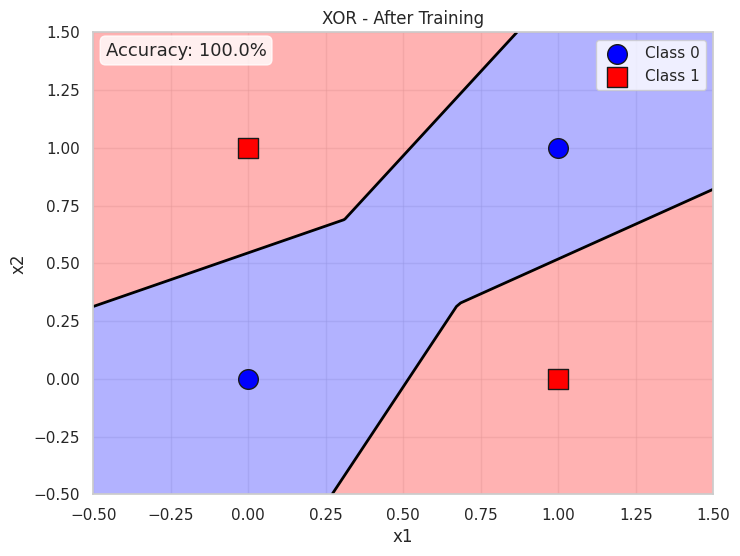

✓ Decision boundary plot logged to W&B dashboard!
Check the 'Media' or 'Files' section of your dashboard to see the plot.


In [94]:
# ANSWER
# Initialize a new W&B run for logging the visualization. Use the same project, use the name "Q4.4 XOR visualization"
run = wandb.init(
    project="csci357-hw03",
    name=f"Q4.2 XOR visualization hid={num_hidden_units} lr={learning_rate}",
    config={
        f"architecture": f"2-{num_hidden_units}-1",
        "dataset": "XOR",
        "epochs": 2000,
        "learning_rate": learning_rate,
        "optimizer": "SGD",
        "loss_function": "BCEWithLogitsLoss"
    }
)






# Call your function to visualize the plot and send it to your wandb run object. Title: "XOR - After Training"
plot_decision_boundary_mlp_wandb(model_xor, X_xor, y_xor, run, "XOR - After Training")

# TODO: Finish the W&B run
run.finish()



print("✓ Decision boundary plot logged to W&B dashboard!")
print("Check the 'Media' or 'Files' section of your dashboard to see the plot.")

## Section 5: Real Data - MNIST Digits

Now let's apply everything we've learned to a real-world dataset: **MNIST handwritten digits**.

MNIST contains 70,000 grayscale images of handwritten digits (0-9), each 28×28 pixels. It's the "Hello World" of computer vision, and represents the example that got the AI field excited again in the late 90s. We discovered that neural nets can be used to process images!

For this section, we'll start with binary classification (digits 0 vs 1), then extend to all 10 digits in the challenges.

> NOTE: If you have worked with PyTorch at all using any large datasets, you are likely quite familiar with the `DataLoader` approach for batching, because real-world data does not all fit in memory! `DataLoader` will be introduced in the coming week or two. We are intentially not using it so we can focus on the MLP training and using the W&B platform. We will integrate it soon!

### 5.1 Loading and Preparing MNIST Data

In this section, we'll download the MNIST dataset using PyTorch's `torchvision.datasets` module. The dataset will be automatically downloaded to a local `./data` directory if it doesn't already exist.

```python
# Download and load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])
```

This code sets up a transformation pipeline for preprocessing MNIST images:

- **`transforms.Compose()`**: Creates a sequence of transformations that will be applied in order to each image
- **`transforms.ToTensor()`**: Converts PIL Image objects (the default format for MNIST) into PyTorch tensors and automatically scales pixel values from the range [0, 255] to [0, 1]
- **`transforms.Normalize((0.5,), (0.5,))`**: Normalizes the tensor using the formula `(x - mean) / std`. With mean=0.5 and std=0.5, this transforms values from [0, 1] to [-1, 1], which centers the data around zero and can improve training stability and convergence

This normalization helps with training stability by centering the data around zero.

Notice that we're loading in both the standard training and testing datasets

In [95]:
from torchvision import datasets, transforms

# Download and load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load training data
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training set size: {len(mnist_train)}")
print(f"Test set size: {len(mnist_test)}")
print(f"Image shape: {mnist_train[0][0].shape}")

Training set size: 60000
Test set size: 10000
Image shape: torch.Size([1, 28, 28])


In the next code cell, we provide a helper function to turn the full MNIST dataset into a **binary classification** problem (two digits only) and prepares the data for training

**`filter_mnist_binary` function**

The function takes an MNIST dataset and two digit labels, and returns images and binary labels for only those two digits.

Parameters<br>
- **`dataset`**: An MNIST-style dataset with `.data` and `.targets`.
- **`digit_a`**, **`digit_b`**: The two digits to keep (e.g. 0 and 1).

Steps inside the function

1. **Index selection**  
   `indices = (dataset.targets == digit_a) | (dataset.targets == digit_b)`  
   Boolean mask of samples whose label is either `digit_a` or `digit_b`.

2. **Subset and normalize**  
   - `dataset.data[indices]` keeps only those samples.  
   - `.float() / 255.0` scales pixel values from 0–255 to **[0, 1]**.

3. **Binary labels**  
   `labels = (labels == digit_b).float()`  
   - Samples with `digit_b` → label **1**.  
   - Samples with `digit_a` → label **0**.  
   So it’s a 0/1 binary target.

4. **Flatten images**  
   `images.view(images.size(0), -1)`  
   Reshapes each 28×28 image into a vector of length **784**, so the feature matrix is **(N, 784)**.

Return value

- **`images`**: shape `(N, 784)`, float in [0, 1].  
- **`labels`**: shape `(N,)`, values 0.0 or 1.0.


Lastly, when we're preparing labels for full-batch training:

```python
y_train_binary = y_train_binary.unsqueeze(1)
y_test_binary = y_test_binary.unsqueeze(1)
```

- **Before**: `y_*_binary` has shape `(N,)`.  
- **After**: shape `(N, 1)`.  
- This matches the typical convention where targets are **(N, 1)** for loss functions and full-batch updates (e.g. MSE with a linear model), so predictions and labels have compatible shapes.

The rest of our example can then use `X_train_binary`, `y_train_binary`, `X_test_binary`, and `y_test_binary` for a binary classifier.

In [96]:
def filter_mnist_binary(dataset, digit_a=0, digit_b=1):
    """
    Filters MNIST dataset to only include two specified digits.

    Args:
        dataset: MNIST dataset.
        digit_a (int): First digit to keep.
        digit_b (int): Second digit to keep.

    Returns:
        tuple: (filtered_images, filtered_labels)
    """
    # Get indices for the two digits
    indices = (dataset.targets == digit_a) | (dataset.targets == digit_b)

    # Extract images and labels
    images = dataset.data[indices].float() / 255.0  # Normalize to [0, 1]
    labels = dataset.targets[indices]

    # Convert labels to binary (0 or 1)
    labels = (labels == digit_b).float()

    # Flatten images: (N, 28, 28) → (N, 784)
    images = images.view(images.size(0), -1)

    return images, labels


# Filter training and test sets for digits 0 and 1
X_train_binary, y_train_binary = filter_mnist_binary(mnist_train, 0, 1)
X_test_binary, y_test_binary = filter_mnist_binary(mnist_test, 0, 1)

print(f"Binary training set: {X_train_binary.shape[0]} samples")
print(f"Binary test set: {X_test_binary.shape[0]} samples")
print(f"Feature dimension: {X_train_binary.shape[1]} (flattened from 28×28)")
print(f"\nLabel distribution in training:")
print(f"  Class 0: {(y_train_binary == 0).sum().item()}")
print(f"  Class 1: {(y_train_binary == 1).sum().item()}")

# Prepare labels for training (add dimension for consistency)
y_train_binary = y_train_binary.unsqueeze(1)
y_test_binary = y_test_binary.unsqueeze(1)

print(f"\nData prepared for full-batch training")
print(f"Training set shape: X={X_train_binary.shape}, y={y_train_binary.shape}")
print(f"Test set shape: X={X_test_binary.shape}, y={y_test_binary.shape}")

Binary training set: 12665 samples
Binary test set: 2115 samples
Feature dimension: 784 (flattened from 28×28)

Label distribution in training:
  Class 0: 5923
  Class 1: 6742

Data prepared for full-batch training
Training set shape: X=torch.Size([12665, 784]), y=torch.Size([12665, 1])
Test set shape: X=torch.Size([2115, 784]), y=torch.Size([2115, 1])


In [97]:
# <div class="todo-box"><h3>TODO</h3></div>

### Question Set 5

Yeah! Now we get to do something a bit more challenging, but still quite within reach. You are going to carefully go through the following cells, and once again, focus on the `# TODO:` sections.

1. Define an MLP with architecture: 784 → 128 → 64 → 1. Use ReLU activations for hidden layers. NOTE: you only need one activation instance, as it does not store gradients. Only the units do.


In [98]:
# ANSWER
class MNIST_MLP(nn.Module):
    """
    Multi-layer perceptron for MNIST binary classification.

    Architecture: 784 → 128 → 64 → 1

    Attributes:
        layer1 (nn.Linear): First linear layer (784 → 128).
        layer2 (nn.Linear): Second linear layer (128 → 64).
        layer3 (nn.Linear): Output layer (64 → 1).
        relu (nn.ReLU): ReLU activation function.
    """

    def __init__(self):
        """
        Initializes the MNIST_MLP model.

        This method sets up the neural network layers for a multi-layer perceptron
        with the following architecture: 784 input features, one hidden layer with 128 units,
        a second hidden layer with 64 units, and an output layer with 1 unit for binary classification.
        Uses ReLU activations for hidden layers.

        Args:
            self: The instance of the MNIST_MLP class.
        """

        # The line below calls the parent class (nn.Module) constructor to properly
        # initialize all inherited components and allow PyTorch to track parameters.
        super().__init__()

        # TODO: Define the layers and activation function
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()




    def forward(self, x):
        """
        Forward pass through the network, returning a logit of shape (N, 1).

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 784).

        Returns:
            torch.Tensor: Output logits of shape (batch_size, 1).
        """

        # TODO: Implement the forward pass
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        return x






2. Instantiate the model. Call it `model_mnist`. Then count the total number of parameters in the model, and of those, the total number of trainable parameters (i.e. those parameters `p` where `p.requires_grad` is `True`.)

In [99]:
# ANSWER

# TODO: Instantiate model, call it model_mnist
model_mnist = MNIST_MLP()

print(model_mnist)

# TODO: Count total and trainable parameters (distinguished by `requires_grad`)
total_params = sum(p.numel() for p in model_mnist.parameters())
trainable_params = sum(p.numel() for p in model_mnist.parameters() if p.requires_grad)

# Print the results
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

MNIST_MLP(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 108,801
Trainable parameters: 108,801


3. Complete the `train_epoch` method below, that trains the model for one epoch. Use full-batch training. Then, implement the `validate` method that simply evaluates the model (i.e. start with `model.eval()`) and returns loss and accuracy just like `train_epoch` does.

In [100]:
# ANSWER
def train_epoch(model, X, y, criterion, optimizer):
    """
    Trains the model for one epoch using full-batch training.

    Args:
        model (nn.Module): Model to train.
        X (torch.Tensor): Full training features tensor.
        y (torch.Tensor): Full training labels tensor.
        criterion: Loss function.
        optimizer: Optimizer.

    Returns:
        tuple: (loss, accuracy)
    """

    # TODO: Implement the training pass for one epoch
    model.train()

    # TODO: Complete theMagic 5 Steps - full batch, no iteration!
    optimizer.zero_grad()
    y_hat = model(X)
    loss = criterion(y_hat, y)
    loss.backward()
    optimizer.step()


    # TODO: generate predictions assuming a sigmoid threshold of 0.5. Calculate accuracy from the predictions and the true labels.
    predictions = (torch.sigmoid(y_hat) > 0.5).float()
    accuracy = (predictions.squeeze() == y.squeeze()).float().mean().item()



    # TODO: return the loss and accuracy
    return loss, accuracy



def validate(model, X, y, criterion):
    """
    Validates the model on a dataset using full-batch evaluation.

    Args:
        model (nn.Module): Model to validate.
        X (torch.Tensor): Full validation features tensor.
        y (torch.Tensor): Full validation labels tensor.
        criterion: Loss function.

    Returns:
        tuple: (loss, accuracy)
    """

    # TODO: Set up the model for evaluation
    model.eval()


    # TODO: generate logits, pass through the criterion to get loss, then generate predictions and calculate accuracy from the predictions and the true labels.
    with torch.no_grad():
        y_hat = model(X)
        loss = criterion(y_hat, y)
        predictions = (torch.sigmoid(y_hat) > 0.5).float()
    
    accuracy = (predictions.squeeze() == y.squeeze()).float().mean().item()
    

    # TODO: return the loss and accuracy
    return loss, accuracy




4. OK, set up your criterion_mnist to be `BCEWithLogitsLoss` and optimizer of `Adam`.

In [101]:
# ANSWER
# Set up our hyperparameters
lr = 0.001

# TODO: Setup criterion and optimizer
criterion_mnist = nn.BCEWithLogitsLoss()
optimizer_mnist = torch.optim.Adam(model_mnist.parameters(), lr=lr)

# Train for a few epochs
num_epochs = 10
print("Training MNIST binary classifier...\n")

# TODO: Implement the training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_mnist, X_train_binary, y_train_binary, criterion_mnist, optimizer_mnist)
    test_loss, test_acc = validate(model_mnist, X_test_binary, y_test_binary, criterion_mnist)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    print(f"  Test  - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

Training MNIST binary classifier...

Epoch 1/10
  Train - Loss: 0.7071, Accuracy: 0.4677
  Test  - Loss: 0.6730, Accuracy: 0.4634
Epoch 2/10
  Train - Loss: 0.6726, Accuracy: 0.4677
  Test  - Loss: 0.6416, Accuracy: 0.4634
Epoch 3/10
  Train - Loss: 0.6415, Accuracy: 0.4677
  Test  - Loss: 0.6077, Accuracy: 0.4634
Epoch 4/10
  Train - Loss: 0.6077, Accuracy: 0.4679
  Test  - Loss: 0.5711, Accuracy: 0.6284
Epoch 5/10
  Train - Loss: 0.5712, Accuracy: 0.6261
  Test  - Loss: 0.5316, Accuracy: 0.8657
Epoch 6/10
  Train - Loss: 0.5318, Accuracy: 0.8662
  Test  - Loss: 0.4893, Accuracy: 0.9480
Epoch 7/10
  Train - Loss: 0.4898, Accuracy: 0.9460
  Test  - Loss: 0.4460, Accuracy: 0.9745
Epoch 8/10
  Train - Loss: 0.4468, Accuracy: 0.9704
  Test  - Loss: 0.4030, Accuracy: 0.9835
Epoch 9/10
  Train - Loss: 0.4042, Accuracy: 0.9785
  Test  - Loss: 0.3612, Accuracy: 0.9896
Epoch 10/10
  Train - Loss: 0.3629, Accuracy: 0.9835
  Test  - Loss: 0.3209, Accuracy: 0.9905


**Excellent!** You should see the model quickly reach >98% accuracy on this binary classification task. This demonstrates the power of MLPs on real-world data.

### 5.2 Visualizing Predictions

With any dataset involving classification of images, it's important to visualize some of your predictions

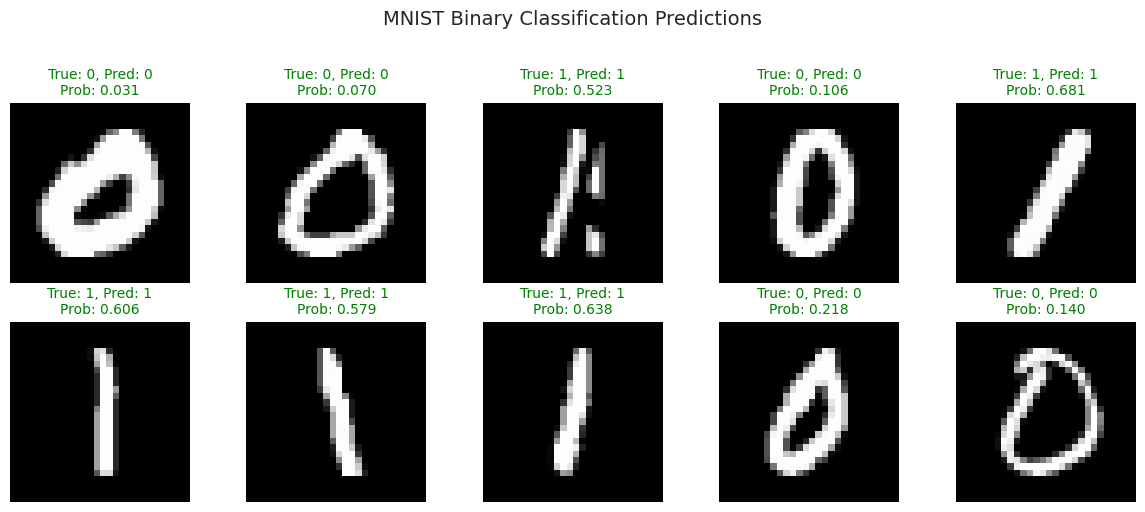

In [102]:
# ANSWER
# Visualize some predictions
model_mnist.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

with torch.no_grad():
    for i in range(10):
        # Get a random test sample
        idx = np.random.randint(0, len(X_test_binary))
        image = X_test_binary[idx].view(28, 28)
        label = y_test_binary[idx].squeeze().item()

        # Predict
        output = model_mnist(X_test_binary[idx].unsqueeze(0))
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0

        # Plot
        axes[i].imshow(image, cmap='gray')
        axes[i].axis('off')
        color = 'green' if pred == label else 'red'
        axes[i].set_title(f'True: {int(label)}, Pred: {pred}\nProb: {prob:.3f}',
                         color=color, fontsize=10)

plt.suptitle('MNIST Binary Classification Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [103]:
# <div class="section-box"><h1>Challenges</h1></div>

# <div class="section-box">Challenges</div>

## Challenge 1: Hyperparameter optimization with W&B

**Objective:** Systematically explore different hyperparameters to find the best configuration for the XOR problem.

> NOTE: Do not use W&B Sweeps dashboard yet. We'll do that in the next assignment.

**Task:**
1. Finish the function below that trains one model with specified hyperparameters
2. Use W&B to run experiments with different combinations of:
   - Learning rates: [0.001, 0.01, 0.1, 0.25, 0.5]
   - Hidden layer sizes: [2, 4, 8, 16]
   - Activation functions: [ReLU, Sigmoid, Tanh]
2. Run at least 12 different experiments
3. Create a summary table comparing all experiments.
4. Summarize in markdown - Which configuration converges fastest? Which achieves the lowest final loss?
5. Use W&B to generate a report for this experiment. Be sure to share the URL publicly, and paste the URL below


In [104]:
# TODO: Implement the class CustomMLP

# Create model with specified activation
class CustomMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, activation):
        """
        A custom multilayer perceptron (MLP) with a single hidden layer and configurable activation function.

        Args:
            input_dim (int): Number of input features.
            hidden_dim (int): Number of neurons in the hidden layer.
            output_dim (int): Number of output features.
            activation (nn.Module): PyTorch activation function (e.g., nn.ReLU(), nn.Sigmoid()).

        Methods:
            forward(x): Performs a forward pass of the MLP on input tensor x.

        """
        # TODO: Initialize the model
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        self.activation = activation



    def forward(self, x):
        """
        Performs a forward pass through the MLP. Returns the logits of the output layer.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim).
        """
        # TODO: Implement the forward pass
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x





In [105]:
# ANSWER
def run_hyperparameter_experiment(learning_rate, hidden_size, activation_name, epochs=2000):
    """
    Runs a single hyperparameter experiment for the XOR problem.

    Args:
        learning_rate (float): Learning rate for optimizer.
        hidden_size (int): Number of neurons in hidden layer.
        activation_name (str): Name of activation function ('relu', 'sigmoid', or 'tanh').
        epochs (int): Number of training epochs.

    Returns:
        dict: Results including the parameters used in this function call, plus final loss, accuracy, and training time.
    """

    # TODO: Initialize W&B with a new project name of csci357-hw03-chal01. Configure the run name to be 
    # lr{learning_rate}_h{hidden_size}_{activation_name}. This is the type of approach you want when you 
    # are running multiple experiments on the same problem.
    # IMPORTANT: pass reinit=True to ensure each run is independent.
    run = wandb.init(
        project="csci357-hw03-chal01",
        name=f"lr{learning_rate}_h{hidden_size}_{activation_name}",
        config={
            f"architecture": f"2-{hidden_size}-1",
            "dataset": "XOR",
            "epochs": epochs,
            "learning_rate": learning_rate,
            "optimizer": "SGD",
            "loss_function": "BCEWithLogitsLoss"
        },
        reinit=True
    )

    # TODO: Instantiate the activation function
    match activation_name:
        case "relu":
            activation = nn.ReLU()
        case "sigmoid":
            activation = nn.Sigmoid()
        case "tanh":
            activation = nn.Tanh()
        case _:
            raise RuntimeError("Invalid activation name")



    # TODO: Instantiate the model, criterion, and optimizer
    model = CustomMLP(2, hidden_size, 1, activation)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


    # TODO: Train and track time. Use our provided function `train_model_with_wandb` we wrote above,
    # passing in the model, X_xor, y_xor, criterion, optimizer, epochs, and print_every parameters
    # Don't forget to compute the training time!
    start_time = time.time()
    losses = train_model_with_wandb(model, X_xor, y_xor, criterion, optimizer, epochs)
    training_time = time.time() - start_time

    # TODO: log the final_loss, final_accuracy, and training_time
    final_loss = losses[-1]
    model.eval()
    with torch.no_grad():
        predictions = model(X_xor)
        preds = (torch.sigmoid(predictions) > 0.5).float()
        final_accuracy = (preds.squeeze() == y_xor.squeeze()).float().mean().item()

    wandb.log({"final_loss": final_loss, "final_accuracy": final_accuracy, "training_time": training_time})

    # TODO: Finish the W&B run
    run.finish()

    # TODO: Return the results as a dictionary
    return {
        "learning_rate": learning_rate,
        "hidden_size": hidden_size,
        "activation": activation_name,
        "final_loss": final_loss,
        "final_accuracy": final_accuracy,
        "training_time": training_time
    }



In [106]:
# Example: Run a few experiments, adjust with your own hyperparameters
results = []
for lr in [0.01, 0.1]:
    for hidden in [4, 8, 12]:
        for act in ['relu', 'tanh']:
            result = run_hyperparameter_experiment(lr, hidden, act)
            results.append(result)

results_df = pd.DataFrame(results)
print(results_df)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 100/2000, Loss: 0.6964, Accuracy: 0.5000
Epoch 200/2000, Loss: 0.6897, Accuracy: 0.5000
Epoch 300/2000, Loss: 0.6865, Accuracy: 0.7500
Epoch 400/2000, Loss: 0.6838, Accuracy: 0.5000
Epoch 500/2000, Loss: 0.6808, Accuracy: 0.5000
Epoch 600/2000, Loss: 0.6773, Accuracy: 0.5000
Epoch 700/2000, Loss: 0.6731, Accuracy: 0.5000
Epoch 800/2000, Loss: 0.6693, Accuracy: 0.5000
Epoch 900/2000, Loss: 0.6659, Accuracy: 0.5000
Epoch 1000/2000, Loss: 0.6623, Accuracy: 0.5000
Epoch 1100/2000, Loss: 0.6584, Accuracy: 0.7500
Epoch 1200/2000, Loss: 0.6541, Accuracy: 0.7500
Epoch 1300/2000, Loss: 0.6494, Accuracy: 0.7500
Epoch 1400/2000, Loss: 0.6444, Accuracy: 0.7500
Epoch 1500/2000, Loss: 0.6389, Accuracy: 0.7500
Epoch 1600/2000, Loss: 0.6333, Accuracy: 0.7500
Epoch 1700/2000, Loss: 0.6273, Accuracy: 0.7500
Epoch 1800/2000, Loss: 0.6210, Accuracy: 0.7500
Epoch 1900/2000, Loss: 0.6144, Accuracy: 0.7500
Epoch 2000/2000, Loss: 0.6078, Accuracy: 0.7500


accuracy,▁▁▁▁▁██▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁████████████████
epoch,▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇██
final_accuracy,▁
final_loss,▁
loss,█▇▇▇▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▁▁▁▁▁
training_time,▁
accuracy,0.75
epoch,1999
final_accuracy,0.75
final_loss,0.60777
loss,0.60777


Epoch 100/2000, Loss: 0.6978, Accuracy: 0.2500
Epoch 200/2000, Loss: 0.6972, Accuracy: 0.5000
Epoch 300/2000, Loss: 0.6967, Accuracy: 0.5000
Epoch 400/2000, Loss: 0.6963, Accuracy: 0.5000
Epoch 500/2000, Loss: 0.6960, Accuracy: 0.5000
Epoch 600/2000, Loss: 0.6957, Accuracy: 0.5000
Epoch 700/2000, Loss: 0.6954, Accuracy: 0.5000
Epoch 800/2000, Loss: 0.6952, Accuracy: 0.5000
Epoch 900/2000, Loss: 0.6950, Accuracy: 0.5000
Epoch 1000/2000, Loss: 0.6948, Accuracy: 0.5000
Epoch 1100/2000, Loss: 0.6946, Accuracy: 0.5000
Epoch 1200/2000, Loss: 0.6944, Accuracy: 0.5000
Epoch 1300/2000, Loss: 0.6942, Accuracy: 0.5000
Epoch 1400/2000, Loss: 0.6940, Accuracy: 0.5000
Epoch 1500/2000, Loss: 0.6939, Accuracy: 0.5000
Epoch 1600/2000, Loss: 0.6937, Accuracy: 0.5000
Epoch 1700/2000, Loss: 0.6935, Accuracy: 0.5000
Epoch 1800/2000, Loss: 0.6934, Accuracy: 0.5000
Epoch 1900/2000, Loss: 0.6932, Accuracy: 0.5000
Epoch 2000/2000, Loss: 0.6930, Accuracy: 0.5000


accuracy,▁▁▁█████████████████████████████████████
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
final_accuracy,▁
final_loss,▁
loss,███▆▆▆▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
training_time,▁
accuracy,0.5
epoch,1999
final_accuracy,0.5
final_loss,0.69304
loss,0.69304


...

Epoch 100/2000, Loss: 0.4829, Accuracy: 1.0000
Epoch 200/2000, Loss: 0.2335, Accuracy: 1.0000
Epoch 300/2000, Loss: 0.1098, Accuracy: 1.0000
Epoch 400/2000, Loss: 0.0622, Accuracy: 1.0000
Epoch 500/2000, Loss: 0.0404, Accuracy: 1.0000
Epoch 600/2000, Loss: 0.0289, Accuracy: 1.0000
Epoch 700/2000, Loss: 0.0219, Accuracy: 1.0000
Epoch 800/2000, Loss: 0.0174, Accuracy: 1.0000
Epoch 900/2000, Loss: 0.0143, Accuracy: 1.0000
Epoch 1000/2000, Loss: 0.0121, Accuracy: 1.0000
Epoch 1100/2000, Loss: 0.0104, Accuracy: 1.0000
Epoch 1200/2000, Loss: 0.0091, Accuracy: 1.0000
Epoch 1300/2000, Loss: 0.0080, Accuracy: 1.0000
Epoch 1400/2000, Loss: 0.0072, Accuracy: 1.0000
Epoch 1500/2000, Loss: 0.0065, Accuracy: 1.0000
Epoch 1600/2000, Loss: 0.0059, Accuracy: 1.0000
Epoch 1700/2000, Loss: 0.0054, Accuracy: 1.0000
Epoch 1800/2000, Loss: 0.0050, Accuracy: 1.0000
Epoch 1900/2000, Loss: 0.0046, Accuracy: 1.0000
Epoch 2000/2000, Loss: 0.0043, Accuracy: 1.0000


accuracy,▁███████████████████████████████████████
epoch,▁▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇█
final_accuracy,▁
final_loss,▁
loss,█▇▅▅▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
training_time,▁
accuracy,1
epoch,1999
final_accuracy,1
final_loss,0.00426
loss,0.00426


Epoch 100/2000, Loss: 0.6753, Accuracy: 0.5000
Epoch 200/2000, Loss: 0.6335, Accuracy: 0.7500
Epoch 300/2000, Loss: 0.5161, Accuracy: 1.0000
Epoch 400/2000, Loss: 0.3243, Accuracy: 1.0000
Epoch 500/2000, Loss: 0.1867, Accuracy: 1.0000
Epoch 600/2000, Loss: 0.1177, Accuracy: 1.0000
Epoch 700/2000, Loss: 0.0820, Accuracy: 1.0000
Epoch 800/2000, Loss: 0.0615, Accuracy: 1.0000
Epoch 900/2000, Loss: 0.0485, Accuracy: 1.0000
Epoch 1000/2000, Loss: 0.0397, Accuracy: 1.0000
Epoch 1100/2000, Loss: 0.0334, Accuracy: 1.0000
Epoch 1200/2000, Loss: 0.0288, Accuracy: 1.0000
Epoch 1300/2000, Loss: 0.0251, Accuracy: 1.0000
Epoch 1400/2000, Loss: 0.0223, Accuracy: 1.0000
Epoch 1500/2000, Loss: 0.0200, Accuracy: 1.0000
Epoch 1600/2000, Loss: 0.0181, Accuracy: 1.0000
Epoch 1700/2000, Loss: 0.0165, Accuracy: 1.0000
Epoch 1800/2000, Loss: 0.0151, Accuracy: 1.0000
Epoch 1900/2000, Loss: 0.0139, Accuracy: 1.0000
Epoch 2000/2000, Loss: 0.0129, Accuracy: 1.0000


accuracy,▁▁▁▅▅███████████████████████████████████
epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇████
final_accuracy,▁
final_loss,▁
loss,███████▇▇▆▄▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
training_time,▁
accuracy,1
epoch,1999
final_accuracy,1
final_loss,0.01293
loss,0.01293


    learning_rate  hidden_size activation  final_loss  final_accuracy  \
0            0.01            4       relu    0.607769            0.75   
1            0.01            4       tanh    0.693038            0.50   
2            0.01            8       relu    0.581284            0.75   
3            0.01            8       tanh    0.603478            0.75   
4            0.01           12       relu    0.321728            1.00   
5            0.01           12       tanh    0.609085            1.00   
6            0.10            4       relu    0.017079            1.00   
7            0.10            4       tanh    0.022900            1.00   
8            0.10            8       relu    0.004809            1.00   
9            0.10            8       tanh    0.010657            1.00   
10           0.10           12       relu    0.004263            1.00   
11           0.10           12       tanh    0.012928            1.00   

    training_time  
0        3.130222  
1        3

**TODO:** In the markdown cell below, summarize your findings, and include a URL to your final result report you generated from W&B. Be sure your report sorts by a meaningful metric to get the best results.. (sort by finall loss or loss)

**ANSWER:**

Analysis: "The best configuration was learning_rate=0.1, hidden_size=12, activation=ReLU, which converged in ~21 epochs with final loss of 0.004263129085302353. Sigmoid activation was significantly slower due to vanishing gradients. Larger hidden layers (12 neurons) improved performance on this simple problem. A larger learning rate also helped the model converge faster for this problem."

https://api.wandb.ai/links/cb073-bucknell-university/fhqlpvfi

## Challenge 2: Multi-Class MNIST (All 10 Digits)

**Objective:** Extend your MLP to classify **all 10 MNIST digits** and explore the impact of hyperparameters on training using Weights & Biases (W&B).

### Key Architecture and Training Changes

1. **Output Layer:**  
   - Update your model's output to **10 neurons** (one per digit, 0–9).
2. **Loss Function:**  
   - Use `nn.CrossEntropyLoss()` for training.  
   - **Important Hint:** `CrossEntropyLoss` expects **raw logits** as its input, so **do NOT add a Softmax layer** at the end of your model! It internally applies `log_softmax` to the logits and computes the loss directly.  
3. **Labels:**  
   - Your ground-truth labels should be integer values from **0–9** (not one-hot vectors, not floats).
4. **Predictions:**  
   - Use `torch.argmax(logits, dim=1)` to get the predicted digit class.

### What to Implement

1. Set up the hyperparameters that you'll play with:
   - num_epochs
   - learning_rate
   - hidden_units (a list of integers representing the number of units in each hidden layer)
   - use_accel (a boolean indicating whether to use the accelerator device)
2. **Data:**  
   - Prepare the full MNIST dataset (all 10 digits).
3. **Model:**  
   - Create an `MNIST_MultiClass` class:
     - Input size = 784, Output = 10  
     - Hidden layers will be configurable as constructor parameter. Default = [128, 64]. Thus, the default architecture is **784 → 128 → 64 → 10**
4. **Device:**  
   - Move the model and X and y train and test tensors to the accelerator device if use_accel is True, otherwise move them to the CPU.
5. **W&B Tracking:**  
   - Initialize with `wandb.init()`; log config (hyperparameters, architecture, etc.).
6. **Training:**  
   - Train on full MNIST for at least **50 epochs**.
   - At *each epoch*:  
     - Log **training loss & accuracy** to W&B  
     - Log **test/validation loss & accuracy**  
     - Use `wandb.watch()` to track gradient & parameter statistics.
4. **Metrics:**  
   - Experiment with configurations until you achieve **>95% test accuracy**.
   - Log a **confusion matrix** to W&B (using `wandb.plot.confusion_matrix` or `wandb.Image`).
   - Visualize **10 misclassified examples** (with predictions) and optionally log images to W&B.
5. **Wrap Up:**  
   - Finish the W&B run with `wandb.finish()`. Unwatch the model with `wandb.unwatch(model)`.

---

**Deliverables:**  
- Trained model with >90% test accuracy  
- W&B dashboard: loss & accuracy curves  
- Confusion matrix visualization (local and W&B)  
- Visual analysis of misclassifications

---

> NOTE: Now is the time you might want to utilize your GPU if you have it. If you're running on Colab, if you choose to disconnect and connect to a new GPU compute instance, remember you'll need to re-run your notebook to reload `wandb`.

In [107]:
# Prepare full MNIST data
def prepare_mnist_full(dataset):
    """Prepares full MNIST dataset (all 10 digits)."""
    images = dataset.data.float() / 255.0
    labels = dataset.targets
    images = images.view(images.size(0), -1)  # Flatten
    return images, labels

X_train_full, y_train_full = prepare_mnist_full(mnist_train)
X_test_full, y_test_full = prepare_mnist_full(mnist_test)

print(f"Full MNIST training set: {len(X_train_full)} samples")
print(f"Full MNIST test set: {len(X_test_full)} samples")
print(f"Number of classes: 10")
print(f"Training set shape: X={X_train_full.shape}, y={y_train_full.shape}")
print(f"Test set shape: X={X_test_full.shape}, y={y_test_full.shape}")

Full MNIST training set: 60000 samples
Full MNIST test set: 10000 samples
Number of classes: 10
Training set shape: X=torch.Size([60000, 784]), y=torch.Size([60000])
Test set shape: X=torch.Size([10000, 784]), y=torch.Size([10000])


Before you implement the class below, look up some examples of using `nn.Sequential`. Since this is an MLP with multiple hidden layers (i.e. deep learning), `nn.Sequential` can be beneficial to use.

`nn.Sequential` allows you to define a feedforward neural network by stacking layers in order. You simply provide a list of layers (such as `nn.Linear` and activation functions like `nn.ReLU()`), and PyTorch will automatically run the input through them in sequence.

By using `nn.Sequential`, your model code will be more concise and easier to modify — you won't have to write individual lines for each layer in the `forward()` function. Instead, all layers are stored in order as a single module, and you just call `self.layers(x)` in the forward pass to compute the output.

See the example below for a basic usage:

```python
self.layers = nn.Sequential(
    nn.Linear(input_dim, hidden1),
    nn.ReLU(),
    nn.Linear(hidden1, hidden2),
    nn.ReLU(),
    nn.Linear(hidden2, output_dim)
)
```

This makes it particularly easy to add, remove, or adjust layers in your network by simply editing the layers in the list. Moreover with the hidden_units parameter, which is a list of integers representing the number of units in each hidden layer, a simple loop will be able to easily make your model.

In [108]:
class MNIST_MultiClass(nn.Module):
    """Multi-layer perceptron for MNIST multi-class classification (10 digits).

    This model implements a fully connected neural network with a configurable
    number of hidden layers and units. ReLU activation functions are used
    between hidden layers. The final output layer produces logits for 10 classes.

    Attributes:
        layers (nn.Sequential): Sequential container of linear layers and ReLU
            activations defining the network architecture.
    """

    def __init__(self, hidden_units=[128, 64]):
        """Initializes the MNIST_MultiClass model.

        Args:
            hidden_units (Optional[List[int]], optional): List of integers specifying the 
                number of neurons in each hidden layer. Defaults to [128, 64].
        """
        super().__init__()

        # TODO: Initialize the model. You should end up with a single nn.Sequential module that is a list of layers and activations.

        input_dim = 784
        output_dim = 10
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_units:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim
            
        layers.append(nn.Linear(prev_dim, output_dim))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        """Compute a forward pass through the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 784).

        Returns:
            torch.Tensor: Logits of shape (batch_size, 10).
        """
        return self.layers(x)



In [109]:
# TODO: Complete the train_epoch_multiclass and validate_multiclass functions

def train_epoch_multiclass(model, X, y, criterion, optimizer, epoch):
    """
    Trains multi-class model for one epoch using full-batch training.

    Args:
        model (torch.nn.Module): The neural network model to train.
        X (torch.Tensor): Input features of shape (batch_size, input_dim).
        y (torch.Tensor): Ground truth labels of shape (batch_size,).
        criterion (torch.nn.Module): Loss function to use for optimization.
        optimizer (torch.optim.Optimizer): Optimizer to update model parameters.

    Returns:
        Tuple[float, float]: The loss value and training accuracy for this epoch.
    """
    # Place model in training mode
    model.train()

    # TODO: Finish training for one epoch
    optimizer.zero_grad()
        
    predictions = model(X)
        
    loss = criterion(predictions, y)
        
    loss.backward()
        
    optimizer.step()


    # Calculate accuracy for binary classification
    # We need to convert logits to probabilities and then to binary predictions
    model.eval()            # Switch to evaluation mode (disables dropout, etc.)
    with torch.no_grad():   # Disable gradient computation for efficiency
        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        preds = predictions.argmax(dim=1)
        # Compare predictions to true labels and calculate mean accuracy
        accuracy = (preds == y).float().mean().item()
        
    model.train()  # Switch back to training mode


    # TODO: Log epoch, loss, and accuracy to W&B
    wandb.log({"epoch": epoch, "loss": loss.item(), "accuracy": accuracy})

    return loss.item(), accuracy

def validate_multiclass(model, X, y, criterion):
    """
    Validates multi-class model using full-batch evaluation.

    Args:
        model (torch.nn.Module): The neural network model for evaluation.
        X (torch.Tensor): Input features of shape (batch_size, input_dim).
        y (torch.Tensor): Ground truth labels of shape (batch_size,).
        criterion (torch.nn.Module): Loss function to use for validation.

    Returns:
        Tuple[float, float]: The loss value and validation accuracy.
    """
    # Set model to evaluation mode
    model.eval()

    # TODO: Finish validation
    
    with torch.no_grad():   # Disable gradient computation for efficiency
        predictions = model(X)
        loss = criterion(predictions, y)
        preds = predictions.argmax(dim=1)
        # Compare predictions to true labels and calculate mean accuracy
        accuracy = (preds == y).float().mean().item()

    return loss.item(), accuracy



Let's introduce a hyperparameter of our own - `use_accel`. If it's `True`, then we need to move the model and all our tensors over to our accelerator defined at the top of this notebook, `accel_device`. If it's false, then just move it back to the `cpu_device` which is also defined for you above. This will let you experiment with your GPU to see how well it improves training time.

In [110]:
# Set up the hyperparameters that you'll play with:
num_epochs = 100
learning_rate = 0.001
hidden_units = [512, 128, 64]
use_accel = False

# Create model
model_multiclass = MNIST_MultiClass(hidden_units=hidden_units)
if use_accel:
    # Move the model and X and y train and test tensors to the accelerator device
    model_multiclass = model_multiclass.to(accel_device)
    X_train_full = X_train_full.to(accel_device)
    y_train_full = y_train_full.to(accel_device)
    X_test_full = X_test_full.to(accel_device)
    y_test_full = y_test_full.to(accel_device)
else:
    model_multiclass = model_multiclass.to(cpu_device)
    X_train_full = X_train_full.to(cpu_device)
    y_train_full = y_train_full.to(cpu_device)
    X_test_full = X_test_full.to(cpu_device)
    y_test_full = y_test_full.to(cpu_device)

criterion_multiclass = nn.CrossEntropyLoss()
optimizer_multiclass = optim.Adam(model_multiclass.parameters(), lr=learning_rate)

print(f"\nModel created with {sum(p.numel() for p in model_multiclass.parameters()):,} parameters")


Model created with 476,490 parameters


We're going to give you this wandb.init. Notice the extras we're throwing into the `config`! Eventually, more challenges will be governed this way. You are submitted to `entity="bucknell-university-csci357-2026sp`. That is the team I set up on W&B for this course. (You will soon be added using your Bucknell address if you haven't already!). The project is set to a string representing this challenge. You have a long name

In [111]:
# Initialize W&B run
wandb.init(
    entity="bucknell-university-csci357-2026sp",
    project="csci357-hw03-MNIST-chal02",
    name=f"{user_initials}-lr{learning_rate}-ep{num_epochs}-hid{hidden_units}-acc={use_accel}",
    config={
        "student_name": user_name,
        "student_id": user_id,
        "student_email": user_email,
        "architecture": f"784-{hidden_units}-10",
        "dataset": "MNIST_full",
        "num_classes": 10,
        "epochs": num_epochs,
        "learning_rate": learning_rate,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss"
    }
)

# Watch the model to track gradients and parameters
wandb.watch(model_multiclass, criterion_multiclass, log="all", log_freq=1)

In [112]:
# Train the model
print("Training MNIST multi-class classifier...\n")

time_start = time.time()
for epoch in range(num_epochs):
    # TODO: Train the model for one epoch
    train_loss, train_acc =train_epoch_multiclass(model_multiclass, X_train_full, y_train_full, criterion_multiclass, optimizer_multiclass, epoch)

    # TODO: Validate the model on the test set
    test_loss, test_acc = validate_multiclass(model_multiclass, X_test_full, y_test_full, criterion_multiclass)


    # TODO: Compute elapsed time
    elapsed_time = time.time() - time_start


    # Log metrics to W&B
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "training_time": elapsed_time
    })

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    print(f"  Test  - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")
    print(f"  Training time: {elapsed_time:.2f} seconds")

# Finish W&B run
wandb.unwatch(model_multiclass)
wandb.finish()
print("\n✓ Challenge 2 complete! Check your W&B dashboard for training curves and confusion matrix.")

Training MNIST multi-class classifier...

Epoch 1/100
  Train - Loss: 2.3046, Accuracy: 0.0937
  Test  - Loss: 2.2805, Accuracy: 0.2403
  Training time: 2.39 seconds
Epoch 2/100
  Train - Loss: 2.2806, Accuracy: 0.2430
  Test  - Loss: 2.2532, Accuracy: 0.3927
  Training time: 4.80 seconds
Epoch 3/100
  Train - Loss: 2.2539, Accuracy: 0.3921
  Test  - Loss: 2.2179, Accuracy: 0.4559
  Training time: 8.33 seconds
Epoch 4/100
  Train - Loss: 2.2192, Accuracy: 0.4561
  Test  - Loss: 2.1724, Accuracy: 0.5317
  Training time: 10.71 seconds
Epoch 5/100
  Train - Loss: 2.1745, Accuracy: 0.5295
  Test  - Loss: 2.1142, Accuracy: 0.5751
  Training time: 12.97 seconds
Epoch 6/100
  Train - Loss: 2.1172, Accuracy: 0.5761
  Test  - Loss: 2.0417, Accuracy: 0.6001
  Training time: 15.30 seconds
Epoch 7/100
  Train - Loss: 2.0458, Accuracy: 0.6021
  Test  - Loss: 1.9548, Accuracy: 0.6316
  Training time: 17.56 seconds
Epoch 8/100
  Train - Loss: 1.9602, Accuracy: 0.6267
  Test  - Loss: 1.8544, Accuracy:

accuracy,▁▅▅▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████████
epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇█████
loss,██▇▇▆▅▅▄▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_accuracy,▁▃▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
test_loss,█▅▅▄▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▄▄▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████
train_loss,██▇▇▆▅▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
training_time,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
accuracy,0.95853
epoch,99
loss,0.14496



✓ Challenge 2 complete! Check your W&B dashboard for training curves and confusion matrix.


## Challenge 3: Confusion Matrix
**Objective:** Visualize the classification performance for all 10 classes
**Tasks:**
1. Use the `confusion_matrix` function from `sklearn.metrics` to create a confusion matrix.
2. Use `seaborn` to plot the confusion matrix as a heatmap.
3. Identify the most confused pair of classes.
4. Visualize the 5 misclassified examples from the most confused pair
5. Visualize 5 misclassified examples from the rest of the classes

Do not run this over and over. Only run this once you found a good model with >95% test accuracy.

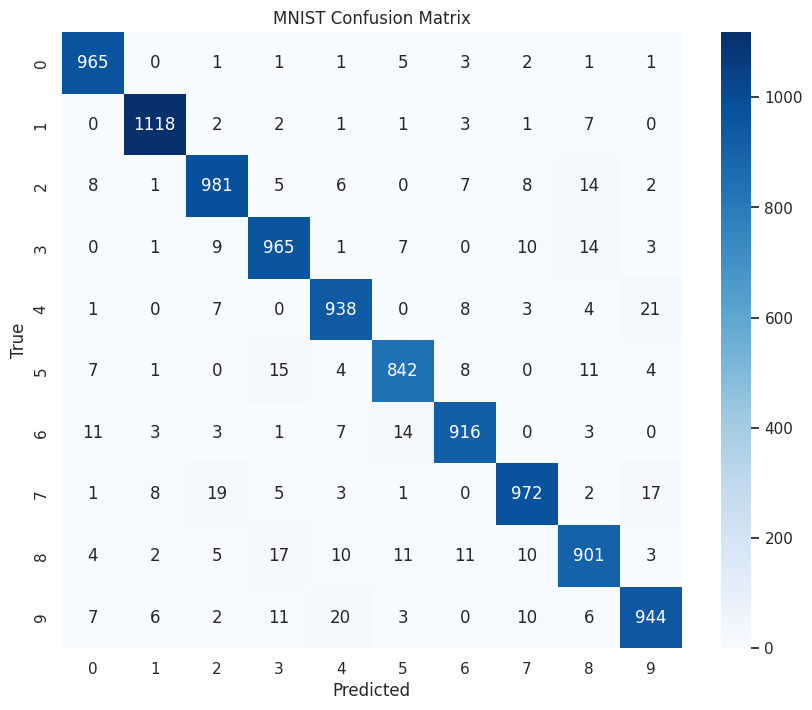

Most confused pair: true 4 predicted as 9 (21 times)


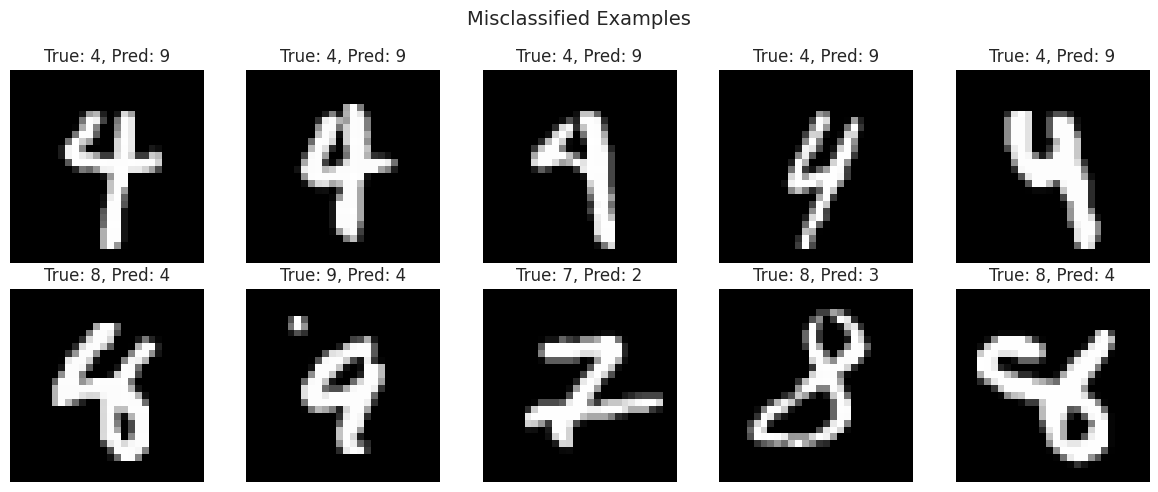

In [ ]:
# ANSWER - Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

model_multiclass.eval()

# TODO: Finish confusion matrix and plot the heatmap using sns.heatmap). Label the axes and title.
with torch.no_grad():
    logits = model_multiclass(X_test_full)
    predictions = logits.argmax(dim=1)
    
c_mat = confusion_matrix(y_test_full.numpy(), predictions.numpy())
plt.figure(figsize=(10, 8))
sns.heatmap(c_mat, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix")
plt.show()

# TODO: Identify most confused label pair (e.g. 1 and 7? 3 and 8? 4 and 9? etc. What did you find?)

# Zero out diagonal (correct predictions)
c_mat_off_diag = c_mat.copy()
np.fill_diagonal(c_mat_off_diag, 0)

# Find max off-diagonal element
max_idx = np.unravel_index(c_mat_off_diag.argmax(), c_mat_off_diag.shape)
print(f"Most confused pair: true {max_idx[0]} predicted as {max_idx[1]} ({c_mat_off_diag[max_idx]} times)")



# TODO: Visualize 10 misclassified examples - 5 from the most confused pair, and 5 of the worst misses overall


# Find all misclassified examples
misclassified_mask = predictions != y_test_full # Create a boolean mask of which predictions were wrong
misclassified_indices = torch.where(misclassified_mask)[0] # Retrieve the sample in the batch (in dim=0)

# Get true labels and predictions for misclassified samples
true_labels = y_test_full[misclassified_indices]
pred_labels = predictions[misclassified_indices]

# --- 5 from most confused pair ---
# (using max_idx from earlier: max_idx[0] = true label, max_idx[1] = predicted label) from off-diag (wrong predictions)
confused_pair_mask = (true_labels == max_idx[0]) & (pred_labels == max_idx[1])
confused_pair_indices = misclassified_indices[confused_pair_mask][:5]

# --- 5 worst misses (highest confidence in wrong class) ---
probs = torch.softmax(logits, dim=1) # Convert logits into probability
pred_confidence = probs.max(dim=1).values  # Confidence in predicted class (choose highest probability)
# Get confidence only for misclassified samples
misclassified_confidence = pred_confidence[misclassified_indices] # Find confidence (highest probability) of misclassified samples
# Sort by confidence (descending) — most confident mistakes first
worst_miss_order = misclassified_confidence.argsort(descending=True)
worst_miss_indices = misclassified_indices[worst_miss_order][:5]

# --- Plot ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Top row: most confused pair
for i, idx in enumerate(confused_pair_indices):
    img = X_test_full[idx].view(28, 28)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'True: {y_test_full[idx].item()}, Pred: {predictions[idx].item()}')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Confused Pair', fontsize=12)

# Bottom row: worst misses
for i, idx in enumerate(worst_miss_indices):
    img = X_test_full[idx].view(28, 28)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'True: {y_test_full[idx].item()}, Pred: {predictions[idx].item()}')
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Worst Misses', fontsize=12)

plt.suptitle('Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()





## Challenge 4: Overfitting Analysis

**Objective:** Understand how model complexity affects overfitting, tracked with W&B.

**Tasks:**
1. Train three models on MNIST binary classification (0 vs 1) with different architectures:
   - **Small**: 784 → 32 → 1
   - **Medium**: 784 → 128 → 64 → 1
   - **Large**: 784 → 512 → 256 → 128 → 1
2. For each model:
   - Initialize a separate W&B run with `wandb.init()` - use descriptive names like "overfitting-small", "overfitting-medium", "overfitting-large"
   - Log the model architecture in the config
   - Track both training and validation loss over 20 epochs, logging both to W&B each epoch using `wandb.log()`
   - Use `wandb.watch()` to monitor gradients (this helps identify overfitting patterns)
   - After training, log the final comparison plot to W&B using `wandb.Image()`
   - Call `wandb.finish()` before moving to the next model
3. Plot train vs. validation loss curves for all three models on the same figure (both locally and in W&B).
4. Answer these questions:
   - Which model overfits the most? How can you tell?
   - Which model generalizes best?
   - What happens to the gap between train and validation loss as model size increases?
5. Suggest two techniques to reduce overfitting (we haven't covered these yet, but research them).

**Deliverables:**
- Three trained models, each tracked in separate W&B runs
- W&B dashboard with three runs showing train/val loss curves (you can compare them side-by-side)
- Comparison plot of train/val loss curves (both local and logged to W&B)
- Written analysis (5-7 sentences)

Training Small model...


Epoch 5: Train Loss=0.5515, Val Loss=0.5147
Epoch 10: Train Loss=0.3756, Val Loss=0.3424
Epoch 15: Train Loss=0.2421, Val Loss=0.2171
Epoch 20: Train Loss=0.1553, Val Loss=0.1366
Epoch 25: Train Loss=0.1019, Val Loss=0.0877
Epoch 30: Train Loss=0.0699, Val Loss=0.0586
Epoch 35: Train Loss=0.0506, Val Loss=0.0414
Epoch 40: Train Loss=0.0386, Val Loss=0.0308
Epoch 45: Train Loss=0.0308, Val Loss=0.0241
Epoch 50: Train Loss=0.0256, Val Loss=0.0197


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_loss,██▇▇▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,▇▇▇████▇▇▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_loss,██▇▇▆▆▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_loss,0.02557
train_val_gap,0.0059
val_loss,0.01967



Training Medium model...


Epoch 5: Train Loss=0.5335, Val Loss=0.4887
Epoch 10: Train Loss=0.3250, Val Loss=0.2888
Epoch 15: Train Loss=0.1795, Val Loss=0.1512
Epoch 20: Train Loss=0.0832, Val Loss=0.0640
Epoch 25: Train Loss=0.0362, Val Loss=0.0247
Epoch 30: Train Loss=0.0175, Val Loss=0.0107
Epoch 35: Train Loss=0.0102, Val Loss=0.0059
Epoch 40: Train Loss=0.0071, Val Loss=0.0040
Epoch 45: Train Loss=0.0055, Val Loss=0.0032
Epoch 50: Train Loss=0.0046, Val Loss=0.0029


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_loss,██▇▇▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,▆▇▇███▇▇▇▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_loss,0.00458
train_val_gap,0.00169
val_loss,0.00289



Training Large model...


Epoch 5: Train Loss=0.4748, Val Loss=0.3668
Epoch 10: Train Loss=0.0459, Val Loss=0.0181
Epoch 15: Train Loss=0.0085, Val Loss=0.0023
Epoch 20: Train Loss=0.0061, Val Loss=0.0015
Epoch 25: Train Loss=0.0040, Val Loss=0.0025
Epoch 30: Train Loss=0.0032, Val Loss=0.0026
Epoch 35: Train Loss=0.0024, Val Loss=0.0037
Epoch 40: Train Loss=0.0018, Val Loss=0.0035
Epoch 45: Train Loss=0.0014, Val Loss=0.0041
Epoch 50: Train Loss=0.0010, Val Loss=0.0036


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,██▇▇▆▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_val_gap,▃▄▅▇██▆▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▆▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_loss,0.00097
train_val_gap,-0.00259
val_loss,0.00356


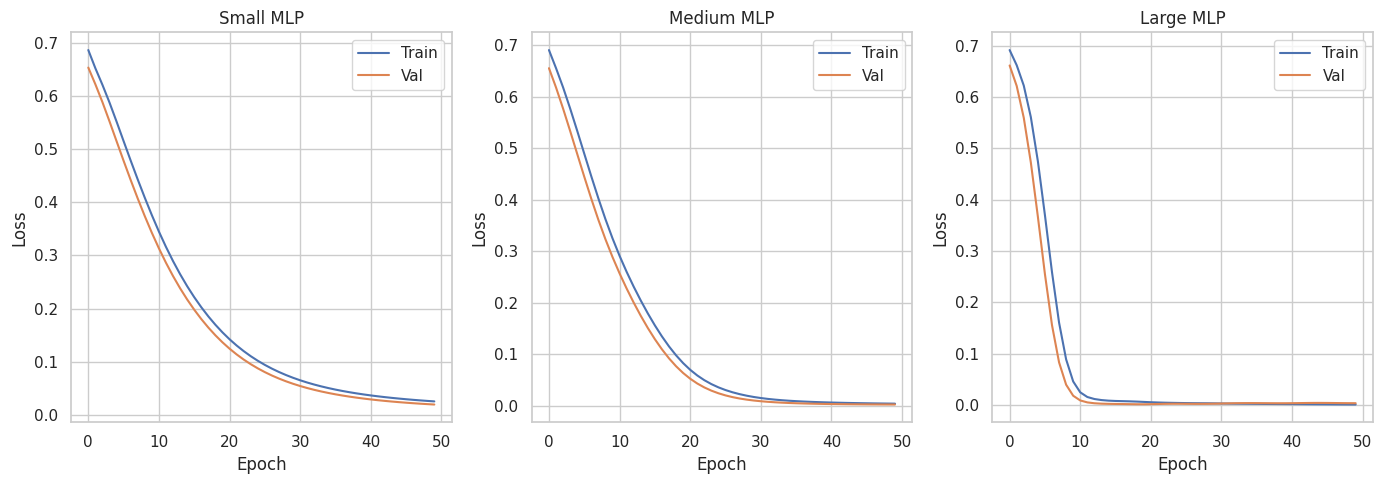


✓ Challenge 4 complete! Check your W&B dashboard to compare all three models side-by-side.


In [114]:
# ANSWER
class SmallMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(784, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)


class MediumMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x)



class LargeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.layers(x)





def train_and_track(model, X_train, y_train, X_test, y_test, epochs=50, model_name="model"):
    """
    Trains a model and tracks train/val losses using full-batch training with W&B logging.

    Args:
        model: Model to train.
        X_train: Training features tensor.
        y_train: Training labels tensor.
        X_test: Test features tensor.
        y_test: Test labels tensor.
        epochs: Number of training epochs.
        model_name: Name for W&B run.

    Returns:
        tuple: (train_losses, val_losses)
    """
    # Initialize W&B run for this model
    wandb.init(
        entity="bucknell-university-csci357-2026sp",
        project="csci357-hw03-MNIST-chal04",
        name=f"{user_initials}-overfitting-{model_name}",
        config={
            "model_name": model_name,
            "epochs": epochs,
            "learning_rate": 0.001,
            "optimizer": "Adam",
            "loss_function": "BCEWithLogitsLoss"
        },
        reinit=True
    )

    # Watch model to track gradients
    wandb.watch(model, log="all", log_freq=5)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # TODO: Train (full batch)
        model.train()
        optimizer.zero_grad()
        train_pred = model(X_train)
        train_loss = criterion(train_pred, y_train)
        train_loss.backward()
        optimizer.step()

        # TODO: Validate (full batch)
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            val_loss = criterion(test_pred, y_test)
        
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        train_val_gap = train_loss.item() - val_loss.item()



        # TODO: Log "epoch", "train_loss", "val_loss", and "train_val_gap" (train_loss - val_loss) to W&B
        wandb.log({"epoch": epoch, "train_loss": train_loss.item(), "val_loss": val_loss.item(), "train_val_gap": train_val_gap})



        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")

    # Finish this W&B run before starting the next model
    wandb.unwatch(model)
    wandb.finish()

    return train_losses, val_losses


# TODO: Train all three models
print("Training Small model...")
small_model = SmallMLP()
small_train, small_val = train_and_track(small_model, X_train_binary, y_train_binary, X_test_binary, y_test_binary, model_name="small")


print("\nTraining Medium model...")
medium_model = MediumMLP()
medium_train, medium_val = train_and_track(medium_model, X_train_binary, y_train_binary, X_test_binary, y_test_binary, model_name="medium")



print("\nTraining Large model...")
large_model = LargeMLP()
large_train, large_val = train_and_track(large_model, X_train_binary, y_train_binary, X_test_binary, y_test_binary, model_name="large")



# TODO: Plot train and validation loss comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(small_train, label='Train')
plt.plot(small_val, label='Val')
plt.title('Small MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 3, 2)
plt.plot(medium_train, label='Train')
plt.plot(medium_val, label='Val')
plt.title('Medium MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()



plt.subplot(1, 3, 3)
plt.plot(large_train, label='Train')
plt.plot(large_val, label='Val')
plt.title('Large MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()



plt.tight_layout()

wandb.init(
    entity="bucknell-university-csci357-2026sp",
    project="csci357-hw03-MNIST-chal04",
    name=f"{user_initials}-overfitting-plot",
    config={"analysis": "overfitting_comparison"},
    reinit=True
)
wandb.log({"overfitting_comparison": wandb.Image(plt)})
wandb.finish()

plt.show()
print("\n✓ Challenge 4 complete! Check your W&B dashboard to compare all three models side-by-side.")

**ANSWER:**

The model that overfits the most is the large model. We can tell my looking at the train and test/validation losses. Here, the training loss is smaller than the validation loss, which indicates that the model has become too accustomed to the training data. The model that generalizes the best is the medium model, where both training and validation losses are similar to each other (while validation loss was lower than training loss) and are very low (near 0). This indicates that with the training the medium model underwent, it was able to predict the test data correctly without becoming too accustomed to the training data. It seems that there is pattern of the training and validation loss gap getting smaller and even becoming negative (overfitting) as model size increases. Some solutions to overfitting are regularization (penalizing large weights to prevent memorization) and dropout (randomly zero out neurons during training to force redundancy). Another method is to just stop training early when validation loss starts increasing.




In [ ]:
# <div class="section-box"><h1>Career Survey</h1></div>

# <div class="section-box">Career Survey</div>

## Humans and AI: The Future of Work

Read this article: https://www.inc.com/rick-locke/choose-the-human-path-for-ai/91290019

Choose 2 of the 4 questions below to answer. 1-2 paragraph answers for each only.

1. The article argues that we face a “Theory X vs. Theory Y” style choice in how we use AI at work: to control/replace workers or to empower them. Take a concrete neural network application you know (e.g., automated hiring filters, medical diagnosis support, trading systems) and analyze how its current or likely deployment reflects “Theory X” versus “Theory Y” assumptions about human workers. What specific design or deployment changes to the model, data pipeline, or human-in-the-loop workflow would be required to shift that application toward the “human path” described in the article, and what technical trade-offs might that introduce (e.g., in accuracy, latency, interpretability)?

2. The article suggests that “the outcome of this era of technological advancement is not yet determined” and that we can still choose to make AI serve human capabilities. From the perspective of someone who designs and trains neural networks, propose one concrete change you would make to standard ML practice (e.g., dataset construction practices, loss design, training objectives, evaluation protocols, or deployment policies) that would meaningfully operationalize this “human path” in real systems. Critically evaluate your own proposal: how might it conflict with common optimization goals in deep learning (such as minimizing error on benchmarks or maximizing user engagement), and what empirical evidence would you need to demonstrate that your change actually improves human outcomes rather than just sounding attractive in principle?

3. As a designer, if a high-performing neural network (99% accuracy) cannot provide a human-readable rationale for its decision, does it inherently follow the 'machine path'? At what point should we sacrifice a few percentage points of accuracy for a model architecture (like a Decision Tree or a modular Glassbox model) that a human can actually audit? How do we technically define 'accountability' in a system where the weights and biases are determined by gradient descent rather than explicit logic?

4. Open-ended. Come up with your own question that challenged you about the article, explain why it was challenging and offer a reflection on it.

**ANSWER 1:**<br>
Question #: 1<br>
Automated hiring filters used in automated tracking systems (ATS) used by HR is exemplary of this Theory X/Theory Y conflict. Currently, they reflect Theory X assumptions where they treat hiring as a filtering problem that aims to eliminate candidates based on keyword matches on their resumes. The recruiter is removed from early stages and people merely become data points. To change this system to a more "human path" would require the model to analyze candidate-specific skills and create insights for recruiters to consider rather than having a pass-fail process. Instead of reviewing the shortlist AI generated, recruiters would use AI to analyze candidates better to know what kinds of questions to ask in interviews. This may introduce latency as each recruiter spends more time per candidate and lead to lower precision on traditional metrics.



**ANSWER 2:**<br>
Question #: 3<br>
A 99% accurate neural network that cannot explain its decision does not inherently follow the machine path, but it can lead to it. The danger isn't the model itself; it's how uninterpretable systems get deployed. When no one can audit the reasoning, organizations tend to either trust it blindly or ignore it. This leads to a Theory X relationship where the human's role is reduced to compliance with the system's outputs. 

The accuracy/transparency trade-off depends on the context. In high-stakes environments like criminal sentencing and medical triage, sacrificing a little bit of accuracy is justified because accountability requires a causal story that we can evaluate. We can't really define accountability in a system guided and optimized by gradient-descent. There is no single reason for any decision or optimization the model makes. However, we could shift accountability from "explain this decision" to "demonstrate this system behaves reliably and fairly across specific conditions" by tackling this issue from a technical approach. Maybe people can audit training data for bias, test edge cases, and detect when a model is operating outside its training distribution.



In [ ]:
# <div class="section-box"><h1>Society</h1></div>

# <div class="section-box">Society</div>

Let's focus on Dario Amodei - CEO of Anthropic. Amodei sells himself and his company, Anthropic, as the leaders of "responsible AI development". They claim to be the leaders in this space. 

Here's a short article of how the AI world views him:
* https://aimagazine.com/news/dario-amodei-transforming-the-future-of-ai-and-work

> **Pro tip**: You should regularly be reading https://aimagazine.com

On January 27, Amodei released a 19,000 word essay, [The Adolescence of Technology](https://www.darioamodei.com/essay/the-adolescence-of-technology). In his essay, he proceed to warn the world about AI. The essay argues that humanity is entering a dangerous “technological adolescence” with AI, in which we gain a “country of geniuses in a datacenter” but lack mature social and political structures to manage the associated risks. Amodei sees powerful AI as plausibly arriving within a few years, defined as systems that vastly outperform top humans across domains, operate autonomously at scale, and can act through digital and physical interfaces. 

Here's a link to an article from The Guardian reporting how the press is responding to this:
* https://www.theguardian.com/technology/2026/jan/27/wake-up-to-the-risks-of-ai-they-are-almost-here-anthropic-boss-warns

Anthropic claims it has grown revenue rapidly “while deploying AI thoughtfully and responsibly. Amodei's company is pushing new models out with new capabilities while the CEO keeps releasing new blog postings on her personal website about the impending challenges of AI to humanity.

Here, Anthropic excitedly reports a hike of 20% in revenue for 2026 (but let's be clear - they are still not profitable.)
https://www.theinformation.com/articles/anthropic-hikes-2026-revenue-forecast-20-delays-will-go-cash-flow-positive

1. If you buy the “technological adolescence” metaphor, what does “adulthood” look like for AI-using societies?
2. Where do you personally sit between “doomerism” and “nothing to see here,” and what evidence would move you?
3. Reflect on this obvious conflict between what Amodei says, and what Amodei and Anthropic are doing. Is this hypocrisy? Or is this just how AI business works today?





**ANSWER:**

**Write a short reflection on each of the 3 questions above:**

1. My vision of a society that has reached "technological adulthood" with regards to AI is one that has learned to incorporate it into daily activities in a responsible way. By this, I mean that people have set political rules restricting AI usage in certain activities and social standards that people (hopefully) live by when dealing with AI. An analogy I would make to help paint this picture better would be the nuclear arms race where, in the beginning, countries were competing to build the first nuclear weapon, but now (for the most part) the world has agreed to put a pause to this.


2. I am leaning more towards the "nothing to see here" because I believe that current ML models are not capable of replacing human intelligence. We have seen massive strides, but I believe that there is still a long way to go before I would say that humanity is doomed. When AI starts to evolve by itself is when I would believe that the end of humanity is nigh.


3. I would not say that it is outright hypocrisy. I think that Amodei understands that current models are not sentient or truly "smart". So, that is why Anthropic continues developing ML models and applications of the technology. However, I also think that at the pace humans are advancing technology, a future where AI becomes uncontrollable (like the one seen in Terminator or I have no mouth, and I must scream) is becoming more likely and possible. I would also argue that Amodei may be doing this to bring more hype and discourage competitors in developing rival products to Anthropic's suite. 




In [ ]:
# <div class="section-box"><h1>AI Usage Disclosure</h1></div>

# <div class="section-box">AI Usage Disclosure</div>

<b>IDE</b>: VSCode with Colab

<b>AI Tools Used</b>: Claude

<b>Short Reflection</b>: I used AI to help find pytorch/python functions and syntax. It was not a hindrance, but it helped me save time from looking through documentation (for quick search).

**AI Chat Dialogs:**

1.
```
Explain the super(CLASSNAME, self) line:

# ANSWER
class SimpleMLP(nn.Module):
    """
    A simple multi-layer perceptron with one hidden layer.

    Architecture: input_dim → hidden_dim (ReLU) → output_dim

    Attributes:
        layer1 (nn.Linear): First linear layer.
        relu (nn.ReLU): ReLU activation function.
        layer2 (nn.Linear): Second linear layer (output).
    """

    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Initializes the SimpleMLP.

        Args:
            input_dim (int): Number of input features.
            hidden_dim (int): Number of neurons in hidden layer.
            output_dim (int): Number of output neurons.
        """
        super(SimpleMLP, self).__init__()

        # Define layers
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).

        Returns:
            torch.Tensor: Output logits of shape (batch_size, output_dim).
        """
        # Pass through first layer
        x = self.layer1(x)
        # Apply ReLU activation
        x = self.relu(x)
        # Pass through output layer
        x = self.layer2(x)
        return x
Show more
11:28 PM
super(SimpleMLP, self).__init__() calls the parent class's __init__ method. Let me break it down:

What super() does:

super(SimpleMLP, self) returns a proxy object that lets you access methods from the parent class (nn.Module). Then .__init__() calls the parent's constructor.

Why it's necessary:

nn.Module does important setup work in its __init__:

Initializes internal bookkeeping for tracking parameters
Sets up the infrastructure for .parameters(), .to(device), .train()/.eval(), etc.
If you skip this call, your model won't work properly—PyTorch won't know about your layers.

The two arguments:

python
super(SimpleMLP, self).__init__()
#     ↑           ↑
#     |           └── the instance we're initializing
#     └── tells super() where to start looking in the inheritance chain
This is Python 2 style syntax. In Python 3, you can just write:

python
super().__init__()  # Equivalent, cleaner
Python 3 figures out the class and instance automatically.

Quick analogy:

Think of it like building a house on a foundation. nn.Module.__init__() lays the foundation (parameter tracking, hooks, etc.), then your __init__ adds the specific rooms (layers). You need the foundation first.
```

2.
```
Does this make sense:

# ANSWER

# TODO: Instantiate model, call it model_mnist
model_mnist = MNIST_MLP()

print(model_mnist)

# TODO: Count total and trainable parameters (distinguished by `requires_grad`)
total_params = model_mnist.parameters()
trainable_params = len([trainable for trainable in model_mnist.parameters() if trainable.requires_grad])

# Print the results
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
Show more
6:11 PM
There are two issues:

1. total_params is a generator, not a count

model_mnist.parameters() returns a generator object, not a number. You need to count the actual parameter elements:

python
total_params = sum(p.numel() for p in model_mnist.parameters())
numel() returns the number of elements in each parameter tensor (e.g., a weight matrix of shape (256, 784) has 200,704 elements).

2. trainable_params counts tensors, not elements

Your code counts how many parameter tensors have requires_grad=True, not the total number of trainable values:

python
# Wrong: counts tensors (e.g., 6 if you have 3 layers with weight + bias each)
trainable_params = len([p for p in model_mnist.parameters() if p.requires_grad])

# Right: counts elements
trainable_params = sum(p.numel() for p in model_mnist.parameters() if p.requires_grad)
```

3.
```
# ANSWER - Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

model_multiclass.eval()

# TODO: Finish confusion matrix and plot the heatmap using sns.heatmap). Label the axes and title.
predictions = model_multiclass(X_test_full)
c_mat = confusion_matrix(y_test_full, predictions)
sns.heatmap(c_mat)




# TODO: Identify most confused label pair (e.g. 1 and 7? 3 and 8? 4 and 9? etc. What did you find?)





# TODO: Visualize 10 misclassified examples - 5 from the most confused pair, and 5 of the worst misses overall
Show less
10:37 PM
A few issues:

1. Need to convert logits to predictions with argmax

confusion_matrix expects class labels, not raw logits:

python
# Wrong
predictions = model_multiclass(X_test_full)
c_mat = confusion_matrix(y_test_full, predictions)  # predictions is (N, 10) logits

# Fixed
with torch.no_grad():
    logits = model_multiclass(X_test_full)
    predictions = logits.argmax(dim=1)
c_mat = confusion_matrix(y_test_full, predictions)
2. Need to convert tensors to numpy for sklearn

python
c_mat = confusion_matrix(y_test_full.numpy(), predictions.numpy())
3. Heatmap needs labels and formatting

python
plt.figure(figsize=(10, 8))
sns.heatmap(c_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MNIST Confusion Matrix')
plt.show()
Fixed code:

python
from sklearn.metrics import confusion_matrix
import seaborn as sns

model_multiclass.eval()

with torch.no_grad():
    logits = model_multiclass(X_test_full)
    predictions = logits.argmax(dim=1)

c_mat = confusion_matrix(y_test_full.numpy(), predictions.numpy())

plt.figure(figsize=(10, 8))
sns.heatmap(c_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MNIST Confusion Matrix')
plt.show()
To find most confused pair:

python
# Zero out diagonal (correct predictions)
c_mat_off_diag = c_mat.copy()
np.fill_diagonal(c_mat_off_diag, 0)

# Find max off-diagonal element
max_idx = np.unravel_index(c_mat_off_diag.argmax(), c_mat_off_diag.shape)
print(f"Most confused pair: true {max_idx[0]} predicted as {max_idx[1]} ({c_mat_off_diag[max_idx]} times)")
what about this:

# TODO: Visualize 10 misclassified examples - 5 from the most confused pair, and 5 of the worst misses overall
10:42 PM
Here's how to do it:

python
# Find all misclassified examples
misclassified_mask = predictions != y_test_full
misclassified_indices = torch.where(misclassified_mask)[0]

# Get true labels and predictions for misclassified samples
true_labels = y_test_full[misclassified_indices]
pred_labels = predictions[misclassified_indices]

# --- 5 from most confused pair ---
# (using max_idx from earlier: max_idx[0] = true label, max_idx[1] = predicted label)
confused_pair_mask = (true_labels == max_idx[0]) & (pred_labels == max_idx[1])
confused_pair_indices = misclassified_indices[confused_pair_mask][:5]

# --- 5 worst misses (largest difference between true and predicted) ---
label_diff = torch.abs(true_labels - pred_labels)
worst_miss_order = label_diff.argsort(descending=True)
worst_miss_indices = misclassified_indices[worst_miss_order][:5]

# --- Plot ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Top row: most confused pair
for i, idx in enumerate(confused_pair_indices):
    img = X_test_full[idx].view(28, 28)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'True: {y_test_full[idx].item()}, Pred: {predictions[idx].item()}')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Confused Pair', fontsize=12)

# Bottom row: worst misses
for i, idx in enumerate(worst_miss_indices):
    img = X_test_full[idx].view(28, 28)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'True: {y_test_full[idx].item()}, Pred: {predictions[idx].item()}')
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Worst Misses', fontsize=12)

plt.suptitle('Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()
Note on "worst misses": I used largest numerical difference (e.g., 0 predicted as 9), but you could define "worst" differently—like lowest confidence or highest loss on that sample. The numerical difference is a simple approximation.
```